## **Baselines Bimodales**

Con los extractores de características seleccionados (**RoBERTa**, **Wav2Vec 2.0**, **ResNet**), que son aquellos que mayor rendimiento conjunto logran para la partición de validación del corpus global, fijando hiperparámetros estándar, a continuación entrenamos y ajustamos los baselines bimodales (**vídeo/audio**, **vídeo/texto**, **texto/audio**) sobre el corpus global unificado para finalmente enfrentarlos a la partición de test del mismo. 

Junto con las baselines unimodales, todos ellos nos permiten cuantificar el beneficio de la fusión en las arquitecturas entrenadas sobre el corpus global unificado.  

Para el ajuste de hiperparámetros, se emplea el mismo proceso utilizado para los baselines unimodales, que también se empleará para las posteriores arquitecturas multimodales, pero en este caso sí probamos con diferentes técnicas de fusión, seleccionando el modelo con aquel tipo de fusión que alcance mayor rendimiento en validación, enfrentándola finalmente a test. 

La arquitectura bimodal cuenta con los mismos componentes que las futuras arquitecturas multimodales de audio, vídeo y texto, y estos son:

1. **Extractores de características**: Modelos preentrenados que obtienen los embeddings de cada modalidad. En concreto, se han fijado aquellos que mayor rendimiento conjunto logras: **RoBERTa**, **Wav2Vec 2.0** y **ResNet**. **Son los mismos empleados por los baselines unimodales y por las futuras arquitecturas multimodales**.

2. **Adaptadores**: Definidos en `adapters.py`, **son los mismos empleados por los baselines unimodales y las futuras arquitecturas multimodales**. Estos proyectan las características en crudo obtenidas por los modelos preentrenados a un espacio latente común de menor dimensionalidad (`proj_dim`), lidiando así mucho mejor con la complejidad de las características inicialmente obtenidas, como sugiere la tendencia actual en el estado del arte para las arquitecturas multimodales. 

3. **Mecanismos de Fusión**: En `fusion_strategies.py` se definen diversos mecanismos a probar. **Son los mismos empleados por las futuras arquitecturas multimodales**:
    - **Fusión Temprana (early fusion)**.
    - **Fusión Tardía mediante voto mayoritario**.
    - **Fusion Tardía mediante promedio**
    - **Fusión Tardía mediante aproximación a Regresión Logística**.
    - **Fusión mediante Atención**.


4. **Clasificador MLP**: Red neuronal MLP que obtiene finalmente el logit final (obligatorio para la función de pérdida `BCEWithLogitsLoss`). **Es la misma empleada por cada técnica de fusión por las futuras arquitecturas multimodales**.

Recordamos el proceso de ajuste de hiperparámetros realizado: 

* **FASE 1: GRID SEARCH de Ventanas de contexto**. Partiendo de la configuración básica para el resto de hiperparámetros (la predeterminada), vamos a realizar una primera búsqueda en rejilla para todas las combinaciones posibles de ventanas de contexto de las modalidades: 

    * **Vídeo**: `32 frames` vs `16 frames`.
    * **Audio**: `11 segundos` vs `7 segundos`.
    * **Texto**: `64 tokens` vs `32 tokens`.

    De esta fase, fijamos **aquella ventana de contexto** con la que mayor F1-Score Macro alcanza el modelo unimodal, superando el umbral de Recall de 0.45 para la clase de Estrés. Ante empate o valores muy ajustados en F1-Score Macro, se fija aquella configuración que obtenga el mayor **Recall** para la clase positiva (Estrés).

* **FASE 2: GRID SEARCH para la Capacidad de la Arquitectura, Regularización y Aprendizaje**. Con las ventanas ya óptimas fijadas, se ajustará el tamaño de la red y su nivel de regularización mediante otro grid search:

    * **Red grande**: `proj_dim = 512` y `hidden_mlp = 128` vs **Red pequeña**:  `proj_dim = 256` y `hidden_mp = 64`.
    * **Dropout**: `0.5`(estándar) vs `0.3`(menor regularización, permite mayor flujo de información). 
    * **Learning Rate (`lr`)**: `1e-4` vs `5e-5` vs `1e-5`. Probamos con valores bajos ya que nuestro dataset es pequeño y desbalanceado, no conviene dar pasos grandes.

Los valores indicados para el ajuste por cada hiperparámetro se han extraído de la literatura (excepto las ventanas, extraídas del EDA). Se han limitado a una cantidad razonable para evitar la explosión combinatoria. Estos mismos hiperparámetros se ajustarán, empleando el mismo proceso de **dos Grid Search** secuenciales, para las arquitecturas multimodales.

Finalmente, los baselines bimodales seleccionados por cada combinación de modalidades (aquellas técnicas de fusión con las que el modelo logra mayor rendimiento tras el ajuste de hiperparámetros en validación), se enfrentan al final del notebook a la partición de **test** del corpus global. 

In [16]:
# Importamos las librerías necesarias:

import os
import json
import matplotlib.pyplot as plt
import subprocess
import pandas as pd
import numpy as np
import re
import matplotlib.patches as mpatches

------
### 1. **Baseline de Vídeo y Audio**

* **Fusión Temprana**:
    * **FASE 1**: 

In [2]:
#-------------------------- Ventanas a ajustar ------------------------

VENTANAS_VIDEO = [32, 16]
VENTANAS_AUDIO = [11, 7]

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'
AUDIO_BACKBONE = 'wav2vec'
lr = 1e-4
do = 0.5
h_mlp = 128
prj_dim = 512

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for video_frames in VENTANAS_VIDEO:
    for audio_len in VENTANAS_AUDIO:

        nombre_base = (f"global_early_{VIDEO_BACKBONE}{video_frames}_{AUDIO_BACKBONE}{audio_len}s_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
        pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
        json_path = f"historial_estres_{nombre_base}.json"

        comando = (f"python train.py "
                    f"--train_dataset global "
                    f"--fusion early "
                    f"--video {VIDEO_BACKBONE} "
                    f"--video_frames {video_frames} "
                    f"--audio {AUDIO_BACKBONE} "
                    f"--audio_len {audio_len} "
                )
                        
        os.system(comando)

        # Extraemos ambas métricas del historial:
        val_f1 = 0.0
        val_recall = 0.0
            
        if os.path.exists(json_path):
            with open(json_path, 'r') as f:
                historial = json.load(f)
                
            # Buscamos el índice de la época con el mejor F1
            mejores_f1_lista = historial['val_f1']
            if mejores_f1_lista:
                mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                val_f1 = historial['val_f1'][mejor_indice]
                val_recall = historial['val_recall_estres'][mejor_indice]

        print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

        # Doble criterio: filtro de recall + selección por F1-Macro
        supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
        mejora_f1 = val_f1 > mejor_f1

        if supera_filtro and mejora_f1:
            # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
            if mejor_config is not None:
                for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

            mejor_f1 = val_f1
            mejor_config = nombre_base
            print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
        else :
            if not supera_filtro:
                print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
            for archivo in [pth_path, json_path]:
                if os.path.exists(archivo):
                    os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: EARLY
--> Vídeo: resnet (32 frames) -> EMBEDDINGS_VISUAL
--> Audio: wav2vec (11s -> 550 pasos) -> EMBEDDINGS_AUDIO


Epoch 1/20: 100%|██████████| 453/453 [00:30<00:00, 14.67it/s, loss=1]    


Epoch 1. Train Loss: 1.0009. Val Loss: 1.1106. Val F1 Macro: 0.5404. Val Recall Estrés: 0.7089

Nuevo mejor modelo: (F1: 0.5404) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 453/453 [00:29<00:00, 15.56it/s, loss=0.93] 


Epoch 2. Train Loss: 0.9719. Val Loss: 1.1295. Val F1 Macro: 0.5446. Val Recall Estrés: 0.6576

Nuevo mejor modelo: (F1: 0.5446) -> Guardando pesos...


...

Epoch 7. Train Loss: 0.8577. Val Loss: 1.1993. Val F1 Macro: 0.5486. Val Recall Estrés: 0.6169

Sin mejora en F1-Score. Límite: 3/5


Epoch 8/20: 100%|██████████| 453/453 [00:23<00:00, 19.54it/s, loss=1.21] 


Epoch 8. Train Loss: 0.8286. Val Loss: 1.3485. Val F1 Macro: 0.5213. Val Recall Estrés: 0.3575

Sin mejora en F1-Score. Límite: 4/5


Epoch 9/20: 100%|██████████| 453/453 [00:22<00:00, 19.82it/s, loss=0.707]


Epoch 9. Train Loss: 0.8066. Val Loss: 1.2057. Val F1 Macro: 0.5346. Val Recall Estrés: 0.6727

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 9 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_global_early_resnet16_wav2vec7s_p512_h128_lr0.0001_do0.5.pth
Historial de entrenamiento guardado en: ./historial_estres_global_early_resnet16_wav2vec7s_p512_h128_lr0.0001_do0.5.json
global_early_resnet16_wav2vec7s_p512_h128_lr0.0001_do0.5 --> F1: 0.5712 | Recall estrés: 0.6109

CONFIGURACIÓN GANADORA: global_early_resnet16_wav2vec11s_p512_h128_lr0.0001_do0.5
Mejor Val F1: 0.5736


Las ventanas óptimas para fusión temprana son de **16 frames** en vídeo y **11 segundos** en audio. 

* **FASE 2:**

In [3]:
#-------------------------- Hiperparámetros a ajustar ------------------------

confg_arq = [(512,128), (256,64)]
LRS = [1e-4,5e-5,1e-5]
dropouts = [0.5, 0.3]

# ------------------------ Valores ya ajustados ------------------------

VENTANA_VIDEO = 16
VENTANA_AUDIO = 11

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'
AUDIO_BACKBONE = 'wav2vec' 

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for prj_dim, h_mlp in confg_arq:
    for lr in LRS:
        for do in dropouts:

            nombre_base = (f"global_early_{VIDEO_BACKBONE}{VENTANA_VIDEO}_{AUDIO_BACKBONE}{VENTANA_AUDIO}s_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
            pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
            json_path = f"historial_estres_{nombre_base}.json"

            comando = (f"python train.py "
                       f"--train_dataset global "
                       f"--fusion early "
                       f"--video {VIDEO_BACKBONE} "
                       f"--video_frames {VENTANA_VIDEO} "
                       f"--audio {AUDIO_BACKBONE} "
                       f"--audio_len {VENTANA_AUDIO} "
                       f"--proj_dim {prj_dim} "
                       f"--hidden_mlp {h_mlp} "
                       f"--lr {lr} "
                       f"--dropout {do} ")
                        
            os.system(comando)

            # Extraemos ambas métricas del historial:
            val_f1 = 0.0
            val_recall = 0.0
            
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    historial = json.load(f)
                
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]

            print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

            # Doble criterio: filtro de recall + selección por F1-Macro
            supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
            mejora_f1 = val_f1 > mejor_f1

            if supera_filtro and mejora_f1:
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None:
                    for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                        if os.path.exists(archivo):
                            os.remove(archivo)

                mejor_f1 = val_f1
                mejor_config = nombre_base
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
            else :
                if not supera_filtro:
                    print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
                for archivo in [pth_path, json_path]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: EARLY
--> Vídeo: resnet (16 frames) -> EMBEDDINGS_VISUAL
--> Audio: wav2vec (11s -> 550 pasos) -> EMBEDDINGS_AUDIO


Epoch 1/20: 100%|██████████| 453/453 [00:28<00:00, 15.95it/s, loss=0.815]


Epoch 1. Train Loss: 1.0028. Val Loss: 1.1050. Val F1 Macro: 0.5479. Val Recall Estrés: 0.6893

Nuevo mejor modelo: (F1: 0.5479) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 453/453 [00:29<00:00, 15.61it/s, loss=1.5]  


Epoch 2. Train Loss: 0.9708. Val Loss: 1.1137. Val F1 Macro: 0.5509. Val Recall Estrés: 0.6410

Nuevo mejor modelo: (F1: 0.5509) -> Guardando pesos...


...

Epoch 10. Train Loss: 0.8545. Val Loss: 1.1862. Val F1 Macro: 0.5597. Val Recall Estrés: 0.5837

Sin mejora en F1-Score. Límite: 3/5


Epoch 11/20: 100%|██████████| 453/453 [00:26<00:00, 17.24it/s, loss=0.896]


Epoch 11. Train Loss: 0.8395. Val Loss: 1.1925. Val F1 Macro: 0.5639. Val Recall Estrés: 0.5762

Sin mejora en F1-Score. Límite: 4/5


Epoch 12/20: 100%|██████████| 453/453 [00:27<00:00, 16.39it/s, loss=0.972]


Epoch 12. Train Loss: 0.8232. Val Loss: 1.2026. Val F1 Macro: 0.5642. Val Recall Estrés: 0.5807

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 12 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_global_early_resnet16_wav2vec11s_p256_h64_lr1e-05_do0.3.pth
Historial de entrenamiento guardado en: ./historial_estres_global_early_resnet16_wav2vec11s_p256_h64_lr1e-05_do0.3.json
global_early_resnet16_wav2vec11s_p256_h64_lr1e-05_do0.3 --> F1: 0.5759 | Recall estrés: 0.6365

CONFIGURACIÓN GANADORA: global_early_resnet16_wav2vec11s_p512_h128_lr1e-05_do0.5
Mejor Val F1: 0.5812


Para la ténica de fusión temprana, la arquitectura finalmente seleccionada para las modalidades de **vídeo y audio**, alcanza un rendimiento de F1 Macro =0.5812 y Recall=0.6229. 

* **Fusión Tardía mediante voto mayoritario:**
    * **FASE 1**:

In [4]:
#-------------------------- Ventanas a ajustar ------------------------

VENTANAS_VIDEO = [32, 16]
VENTANAS_AUDIO = [11, 7]

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'
AUDIO_BACKBONE = 'wav2vec'
lr = 1e-4
do = 0.5
h_mlp = 128
prj_dim = 512

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for video_frames in VENTANAS_VIDEO:
    for audio_len in VENTANAS_AUDIO:

        nombre_base = (f"global_late_voto_{VIDEO_BACKBONE}{video_frames}_{AUDIO_BACKBONE}{audio_len}s_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
        pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
        json_path = f"historial_estres_{nombre_base}.json"

        comando = (f"python train.py "
                    f"--train_dataset global "
                    f"--fusion late "
                    f"--late_mode voto "
                    f"--video {VIDEO_BACKBONE} "
                    f"--video_frames {video_frames} "
                    f"--audio {AUDIO_BACKBONE} "
                    f"--audio_len {audio_len} ")
                        
        os.system(comando)

        # Extraemos ambas métricas del historial:
        val_f1 = 0.0
        val_recall = 0.0
            
        if os.path.exists(json_path):
            with open(json_path, 'r') as f:
                historial = json.load(f)
                
            # Buscamos el índice de la época con el mejor F1
            mejores_f1_lista = historial['val_f1']
            if mejores_f1_lista:
                mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                val_f1 = historial['val_f1'][mejor_indice]
                val_recall = historial['val_recall_estres'][mejor_indice]

        print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

        # Doble criterio: filtro de recall + selección por F1-Macro
        supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
        mejora_f1 = val_f1 > mejor_f1

        if supera_filtro and mejora_f1:
            # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
            if mejor_config is not None:
                for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

            mejor_f1 = val_f1
            mejor_config = nombre_base
            print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
        else :
            if not supera_filtro:
                print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
            for archivo in [pth_path, json_path]:
                if os.path.exists(archivo):
                    os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

Epoch 1/20:   0%|          | 0/453 [00:00<?, ?it/s]

DETECCIÓN DE ESTRÉS: 
--> Fusión: LATE
--> Vídeo: resnet (32 frames) -> EMBEDDINGS_VISUAL
--> Audio: wav2vec (11s -> 550 pasos) -> EMBEDDINGS_AUDIO


Epoch 2/20:   0%|          | 2/453 [00:00<00:31, 14.38it/s, loss=0.942]

Epoch 1. Train Loss: 1.0187. Val Loss: 1.0944. Val F1 Macro: 0.5337. Val Recall Estrés: 0.7255

Nuevo mejor modelo: (F1: 0.5337) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 453/453 [00:30<00:00, 14.65it/s, loss=0.816]


...

Epoch 7. Train Loss: 0.8926. Val Loss: 1.1212. Val F1 Macro: 0.5605. Val Recall Estrés: 0.6259

Sin mejora en F1-Score. Límite: 3/5


Epoch 8/20: 100%|██████████| 453/453 [00:22<00:00, 20.18it/s, loss=1.22] 


Epoch 8. Train Loss: 0.8794. Val Loss: 1.1134. Val F1 Macro: 0.5531. Val Recall Estrés: 0.6516

Sin mejora en F1-Score. Límite: 4/5


Epoch 9/20: 100%|██████████| 453/453 [00:23<00:00, 19.05it/s, loss=0.917]


Epoch 9. Train Loss: 0.8640. Val Loss: 1.1378. Val F1 Macro: 0.5435. Val Recall Estrés: 0.6244

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 9 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_global_late_voto_resnet16_wav2vec7s_p512_h128_lr0.0001_do0.5.pth
Historial de entrenamiento guardado en: ./historial_estres_global_late_voto_resnet16_wav2vec7s_p512_h128_lr0.0001_do0.5.json
global_late_voto_resnet16_wav2vec7s_p512_h128_lr0.0001_do0.5 --> F1: 0.5745 | Recall estrés: 0.6229
--> NUEVO MEJOR MODELO (F1=0.5745 | Recall=0.6229): global_late_voto_resnet16_wav2vec7s_p512_h128_lr0.0001_do0.5

CONFIGURACIÓN GANADORA: global_late_voto_resnet16_wav2vec7s_p512_h128_lr0.0001_do0.5
Mejor Val F1: 0.5745


Las ventanas óptimas para la fusión tardía mediante voto mayoritario es de **16 frames** para vídeo, y de **7 segundos** para audio. 

* **FASE 2**:

In [5]:
#-------------------------- Hiperparámetros a ajustar ------------------------

confg_arq = [(512,128), (256,64)]
LRS = [1e-4,5e-5,1e-5]
dropouts = [0.5, 0.3]

# ------------------------ Valores ya ajustados ------------------------

VENTANA_VIDEO = 16
VENTANA_AUDIO = 7

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'
AUDIO_BACKBONE = 'wav2vec' 

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for prj_dim, h_mlp in confg_arq:
    for lr in LRS:
        for do in dropouts:

            nombre_base = (f"global_late_voto_{VIDEO_BACKBONE}{VENTANA_VIDEO}_{AUDIO_BACKBONE}{VENTANA_AUDIO}s_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
            pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
            json_path = f"historial_estres_{nombre_base}.json"

            comando = (f"python train.py "
                       f"--train_dataset global "
                       f"--fusion late "
                       f"--late_mode voto "
                       f"--video {VIDEO_BACKBONE} "
                       f"--video_frames {VENTANA_VIDEO} "
                       f"--audio {AUDIO_BACKBONE} "
                       f"--audio_len {VENTANA_AUDIO} "
                       f"--proj_dim {prj_dim} "
                       f"--hidden_mlp {h_mlp} "
                       f"--lr {lr} "
                       f"--dropout {do} ")
                        
            os.system(comando)

            # Extraemos ambas métricas del historial:
            val_f1 = 0.0
            val_recall = 0.0
            
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    historial = json.load(f)
                
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]

            print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

            # Doble criterio: filtro de recall + selección por F1-Macro
            supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
            mejora_f1 = val_f1 > mejor_f1

            if supera_filtro and mejora_f1:
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None:
                    for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                        if os.path.exists(archivo):
                            os.remove(archivo)

                mejor_f1 = val_f1
                mejor_config = nombre_base
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
            else :
                if not supera_filtro:
                    print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
                for archivo in [pth_path, json_path]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: LATE
--> Vídeo: resnet (16 frames) -> EMBEDDINGS_VISUAL
--> Audio: wav2vec (7s -> 350 pasos) -> EMBEDDINGS_AUDIO


Epoch 1/20: 100%|██████████| 453/453 [00:23<00:00, 19.45it/s, loss=1.51] 


Epoch 1. Train Loss: 1.0262. Val Loss: 1.0977. Val F1 Macro: 0.5649. Val Recall Estrés: 0.6320

Nuevo mejor modelo: (F1: 0.5649) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 453/453 [00:22<00:00, 20.20it/s, loss=0.833]


Epoch 2. Train Loss: 0.9684. Val Loss: 1.0835. Val F1 Macro: 0.5600. Val Recall Estrés: 0.6833

Sin mejora en F1-Score. Límite: 1/5


...

Epoch 17. Train Loss: 0.7975. Val Loss: 1.1117. Val F1 Macro: 0.5474. Val Recall Estrés: 0.6546

Sin mejora en F1-Score. Límite: 3/5


Epoch 18/20: 100%|██████████| 453/453 [00:19<00:00, 23.32it/s, loss=0.674]


Epoch 18. Train Loss: 0.7903. Val Loss: 1.1189. Val F1 Macro: 0.5337. Val Recall Estrés: 0.6606

Sin mejora en F1-Score. Límite: 4/5


Epoch 19/20: 100%|██████████| 453/453 [00:22<00:00, 19.86it/s, loss=0.626]


Epoch 19. Train Loss: 0.7793. Val Loss: 1.1072. Val F1 Macro: 0.5368. Val Recall Estrés: 0.6923

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 19 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_global_late_voto_resnet16_wav2vec7s_p256_h64_lr1e-05_do0.3.pth
Historial de entrenamiento guardado en: ./historial_estres_global_late_voto_resnet16_wav2vec7s_p256_h64_lr1e-05_do0.3.json
global_late_voto_resnet16_wav2vec7s_p256_h64_lr1e-05_do0.3 --> F1: 0.5599 | Recall estrés: 0.6546

CONFIGURACIÓN GANADORA: global_late_voto_resnet16_wav2vec7s_p512_h128_lr1e-05_do0.5
Mejor Val F1: 0.5798


Para la ténica de fusión tardía mediante voto mayoritario, la arquitectura finalmente seleccionada para las modalidades de **vídeo y audio**, alcanza un rendimiento de F1 Macro =0.5798 y Recall=0.6350. 

* **Fusión Tardía mediante promedio**:
    * **FASE 1**:

In [7]:
#-------------------------- Ventanas a ajustar ------------------------

VENTANAS_VIDEO = [32, 16]
VENTANAS_AUDIO = [11, 7]

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'
AUDIO_BACKBONE = 'wav2vec'
lr = 1e-4
do = 0.5
h_mlp = 128
prj_dim = 512

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for video_frames in VENTANAS_VIDEO:
    for audio_len in VENTANAS_AUDIO:

        nombre_base = (f"global_late_promedio_{VIDEO_BACKBONE}{video_frames}_{AUDIO_BACKBONE}{audio_len}s_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
        pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
        json_path = f"historial_estres_{nombre_base}.json"

        comando = (f"python train.py "
                    f"--train_dataset global "
                    f"--fusion late "
                    f"--late_mode promedio "
                    f"--video {VIDEO_BACKBONE} "
                    f"--video_frames {video_frames} "
                    f"--audio {AUDIO_BACKBONE} "
                    f"--audio_len {audio_len} ")
                        
        os.system(comando)

        # Extraemos ambas métricas del historial:
        val_f1 = 0.0
        val_recall = 0.0
            
        if os.path.exists(json_path):
            with open(json_path, 'r') as f:
                historial = json.load(f)
                
            # Buscamos el índice de la época con el mejor F1
            mejores_f1_lista = historial['val_f1']
            if mejores_f1_lista:
                mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                val_f1 = historial['val_f1'][mejor_indice]
                val_recall = historial['val_recall_estres'][mejor_indice]

        print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

        # Doble criterio: filtro de recall + selección por F1-Macro
        supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
        mejora_f1 = val_f1 > mejor_f1

        if supera_filtro and mejora_f1:
            # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
            if mejor_config is not None:
                for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

            mejor_f1 = val_f1
            mejor_config = nombre_base
            print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
        else :
            if not supera_filtro:
                print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
            for archivo in [pth_path, json_path]:
                if os.path.exists(archivo):
                    os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: LATE
--> Vídeo: resnet (32 frames) -> EMBEDDINGS_VISUAL
--> Audio: wav2vec (11s -> 550 pasos) -> EMBEDDINGS_AUDIO


Epoch 2/20:   0%|          | 2/453 [00:00<00:39, 11.31it/s, loss=0.782]

Epoch 1. Train Loss: 0.9740. Val Loss: 1.1603. Val F1 Macro: 0.5413. Val Recall Estrés: 0.7240

Nuevo mejor modelo: (F1: 0.5413) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 453/453 [00:30<00:00, 14.65it/s, loss=1.11] 


Epoch 2. Train Loss: 0.9491. Val Loss: 1.1255. Val F1 Macro: 0.5748. Val Recall Estrés: 0.6802

Nuevo mejor modelo: (F1: 0.5748) -> Guardando pesos...


...

Epoch 8. Train Loss: 0.7910. Val Loss: 1.2188. Val F1 Macro: 0.5435. Val Recall Estrés: 0.5928

Sin mejora en F1-Score. Límite: 3/5


Epoch 9/20: 100%|██████████| 453/453 [00:21<00:00, 21.15it/s, loss=0.798]


Epoch 9. Train Loss: 0.7613. Val Loss: 1.2628. Val F1 Macro: 0.5462. Val Recall Estrés: 0.6531

Sin mejora en F1-Score. Límite: 4/5


Epoch 10/20: 100%|██████████| 453/453 [00:21<00:00, 21.15it/s, loss=0.78] 


Epoch 10. Train Loss: 0.7383. Val Loss: 1.3340. Val F1 Macro: 0.5453. Val Recall Estrés: 0.6018

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 10 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_global_late_promedio_resnet16_wav2vec7s_p512_h128_lr0.0001_do0.5.pth
Historial de entrenamiento guardado en: ./historial_estres_global_late_promedio_resnet16_wav2vec7s_p512_h128_lr0.0001_do0.5.json
global_late_promedio_resnet16_wav2vec7s_p512_h128_lr0.0001_do0.5 --> F1: 0.5695 | Recall estrés: 0.5747

CONFIGURACIÓN GANADORA: global_late_promedio_resnet32_wav2vec7s_p512_h128_lr0.0001_do0.5
Mejor Val F1: 0.5784


Las ventanas óptimas para la fusión tardía mediante promedio para **vídeo** y **audio** son de **32 frames** y **7 segundos**, respectivamente. 

* **FASE 2**:

In [8]:
#-------------------------- Hiperparámetros a ajustar ------------------------

confg_arq = [(512,128), (256,64)]
LRS = [1e-4,5e-5,1e-5]
dropouts = [0.5, 0.3]

# ------------------------ Valores ya ajustados ------------------------

VENTANA_VIDEO = 32
VENTANA_AUDIO = 7

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'
AUDIO_BACKBONE = 'wav2vec' 

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for prj_dim, h_mlp in confg_arq:
    for lr in LRS:
        for do in dropouts:

            nombre_base = (f"global_late_promedio_{VIDEO_BACKBONE}{VENTANA_VIDEO}_{AUDIO_BACKBONE}{VENTANA_AUDIO}s_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
            pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
            json_path = f"historial_estres_{nombre_base}.json"

            comando = (f"python train.py "
                       f"--train_dataset global "
                       f"--fusion late "
                       f"--late_mode promedio "
                       f"--video {VIDEO_BACKBONE} "
                       f"--video_frames {VENTANA_VIDEO} "
                       f"--audio {AUDIO_BACKBONE} "
                       f"--audio_len {VENTANA_AUDIO} "
                       f"--proj_dim {prj_dim} "
                       f"--hidden_mlp {h_mlp} "
                       f"--lr {lr} "
                       f"--dropout {do} ")
                        
            os.system(comando)

            # Extraemos ambas métricas del historial:
            val_f1 = 0.0
            val_recall = 0.0
            
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    historial = json.load(f)
                
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]

            print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

            # Doble criterio: filtro de recall + selección por F1-Macro
            supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
            mejora_f1 = val_f1 > mejor_f1

            if supera_filtro and mejora_f1:
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None:
                    for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                        if os.path.exists(archivo):
                            os.remove(archivo)

                mejor_f1 = val_f1
                mejor_config = nombre_base
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
            else :
                if not supera_filtro:
                    print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
                for archivo in [pth_path, json_path]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: LATE
--> Vídeo: resnet (32 frames) -> EMBEDDINGS_VISUAL
--> Audio: wav2vec (7s -> 350 pasos) -> EMBEDDINGS_AUDIO


Epoch 1/20: 100%|██████████| 453/453 [00:22<00:00, 20.42it/s, loss=1.16] 


Epoch 1. Train Loss: 0.9718. Val Loss: 1.0838. Val F1 Macro: 0.5525. Val Recall Estrés: 0.6802

Nuevo mejor modelo: (F1: 0.5525) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 453/453 [00:22<00:00, 20.23it/s, loss=1.12] 


Epoch 2. Train Loss: 0.9397. Val Loss: 1.1201. Val F1 Macro: 0.5663. Val Recall Estrés: 0.5324

Nuevo mejor modelo: (F1: 0.5663) -> Guardando pesos...


...

Epoch 8. Train Loss: 0.8603. Val Loss: 1.1725. Val F1 Macro: 0.5493. Val Recall Estrés: 0.4977

Sin mejora en F1-Score. Límite: 3/5


Epoch 9/20: 100%|██████████| 453/453 [00:20<00:00, 22.13it/s, loss=0.92] 


Epoch 9. Train Loss: 0.8408. Val Loss: 1.1662. Val F1 Macro: 0.5441. Val Recall Estrés: 0.4766

Sin mejora en F1-Score. Límite: 4/5


Epoch 10/20: 100%|██████████| 453/453 [00:21<00:00, 20.90it/s, loss=0.719]


Epoch 10. Train Loss: 0.8273. Val Loss: 1.1882. Val F1 Macro: 0.5385. Val Recall Estrés: 0.4585

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 10 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_global_late_promedio_resnet32_wav2vec7s_p256_h64_lr1e-05_do0.3.pth
Historial de entrenamiento guardado en: ./historial_estres_global_late_promedio_resnet32_wav2vec7s_p256_h64_lr1e-05_do0.3.json
global_late_promedio_resnet32_wav2vec7s_p256_h64_lr1e-05_do0.3 --> F1: 0.5645 | Recall estrés: 0.6742

CONFIGURACIÓN GANADORA: global_late_promedio_resnet32_wav2vec7s_p512_h128_lr1e-05_do0.5
Mejor Val F1: 0.5782


El modelo ajustado en fusión tardía mediante promedio para **vídeo** y **audio** alcanza un rendimiento de F1 Macro =0.5782 y Recall=0.6184

* **Fusión Tardía mediante aproximación a Regresión Logísticas**:
    * **FASE 1**:

In [9]:
#-------------------------- Ventanas a ajustar ------------------------

VENTANAS_VIDEO = [32, 16]
VENTANAS_AUDIO = [11, 7]

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'
AUDIO_BACKBONE = 'wav2vec'
lr = 1e-4
do = 0.5
h_mlp = 128
prj_dim = 512

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for video_frames in VENTANAS_VIDEO:
    for audio_len in VENTANAS_AUDIO:

        nombre_base = (f"global_late_logistica_{VIDEO_BACKBONE}{video_frames}_{AUDIO_BACKBONE}{audio_len}s_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
        pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
        json_path = f"historial_estres_{nombre_base}.json"

        comando = (f"python train.py "
                    f"--train_dataset global "
                    f"--fusion late "
                    f"--late_mode logistica "
                    f"--video {VIDEO_BACKBONE} "
                    f"--video_frames {video_frames} "
                    f"--audio {AUDIO_BACKBONE} "
                    f"--audio_len {audio_len} ")
                        
        os.system(comando)

        # Extraemos ambas métricas del historial:
        val_f1 = 0.0
        val_recall = 0.0
            
        if os.path.exists(json_path):
            with open(json_path, 'r') as f:
                historial = json.load(f)
                
            # Buscamos el índice de la época con el mejor F1
            mejores_f1_lista = historial['val_f1']
            if mejores_f1_lista:
                mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                val_f1 = historial['val_f1'][mejor_indice]
                val_recall = historial['val_recall_estres'][mejor_indice]

        print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

        # Doble criterio: filtro de recall + selección por F1-Macro
        supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
        mejora_f1 = val_f1 > mejor_f1

        if supera_filtro and mejora_f1:
            # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
            if mejor_config is not None:
                for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

            mejor_f1 = val_f1
            mejor_config = nombre_base
            print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
        else :
            if not supera_filtro:
                print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
            for archivo in [pth_path, json_path]:
                if os.path.exists(archivo):
                    os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: LATE
--> Vídeo: resnet (32 frames) -> EMBEDDINGS_VISUAL
--> Audio: wav2vec (11s -> 550 pasos) -> EMBEDDINGS_AUDIO


Epoch 1/20: 100%|██████████| 453/453 [00:36<00:00, 12.35it/s, loss=0.908]


Epoch 1. Train Loss: 1.0331. Val Loss: 1.0972. Val F1 Macro: 0.5648. Val Recall Estrés: 0.6335

Nuevo mejor modelo: (F1: 0.5648) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 453/453 [00:30<00:00, 14.74it/s, loss=1.07] 


Epoch 2. Train Loss: 0.9497. Val Loss: 1.1112. Val F1 Macro: 0.5671. Val Recall Estrés: 0.5294

Nuevo mejor modelo: (F1: 0.5671) -> Guardando pesos...


...

Epoch 7. Train Loss: 0.8057. Val Loss: 1.2130. Val F1 Macro: 0.5480. Val Recall Estrés: 0.6546

Sin mejora en F1-Score. Límite: 3/5


Epoch 8/20: 100%|██████████| 453/453 [00:23<00:00, 19.41it/s, loss=1.14] 


Epoch 8. Train Loss: 0.7812. Val Loss: 1.1995. Val F1 Macro: 0.5443. Val Recall Estrés: 0.6199

Sin mejora en F1-Score. Límite: 4/5


Epoch 9/20: 100%|██████████| 453/453 [00:20<00:00, 21.74it/s, loss=1.02] 


Epoch 9. Train Loss: 0.7542. Val Loss: 1.2315. Val F1 Macro: 0.5556. Val Recall Estrés: 0.6471

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 9 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_global_late_logistica_resnet16_wav2vec7s_p512_h128_lr0.0001_do0.5.pth
Historial de entrenamiento guardado en: ./historial_estres_global_late_logistica_resnet16_wav2vec7s_p512_h128_lr0.0001_do0.5.json
global_late_logistica_resnet16_wav2vec7s_p512_h128_lr0.0001_do0.5 --> F1: 0.5758 | Recall estrés: 0.5792
--> NUEVO MEJOR MODELO (F1=0.5758 | Recall=0.5792): global_late_logistica_resnet16_wav2vec7s_p512_h128_lr0.0001_do0.5

CONFIGURACIÓN GANADORA: global_late_logistica_resnet16_wav2vec7s_p512_h128_lr0.0001_do0.5
Mejor Val F1: 0.5758


Las ventanas óptimas son **16 frames** en vídeo y **7 segundos** en audio.

* **FASE 2**:

In [10]:
#-------------------------- Hiperparámetros a ajustar ------------------------

confg_arq = [(512,128), (256,64)]
LRS = [1e-4,5e-5,1e-5]
dropouts = [0.5, 0.3]

# ------------------------ Valores ya ajustados ------------------------

VENTANA_VIDEO = 16
VENTANA_AUDIO = 7

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'
AUDIO_BACKBONE = 'wav2vec' 

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for prj_dim, h_mlp in confg_arq:
    for lr in LRS:
        for do in dropouts:

            nombre_base = (f"global_late_logistica_{VIDEO_BACKBONE}{VENTANA_VIDEO}_{AUDIO_BACKBONE}{VENTANA_AUDIO}s_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
            pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
            json_path = f"historial_estres_{nombre_base}.json"

            comando = (f"python train.py "
                       f"--train_dataset global "
                       f"--fusion late "
                       f"--late_mode logistica "
                       f"--video {VIDEO_BACKBONE} "
                       f"--video_frames {VENTANA_VIDEO} "
                       f"--audio {AUDIO_BACKBONE} "
                       f"--audio_len {VENTANA_AUDIO} "
                       f"--proj_dim {prj_dim} "
                       f"--hidden_mlp {h_mlp} "
                       f"--lr {lr} "
                       f"--dropout {do} ")
                        
            os.system(comando)

            # Extraemos ambas métricas del historial:
            val_f1 = 0.0
            val_recall = 0.0
            
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    historial = json.load(f)
                
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]

            print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

            # Doble criterio: filtro de recall + selección por F1-Macro
            supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
            mejora_f1 = val_f1 > mejor_f1

            if supera_filtro and mejora_f1:
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None:
                    for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                        if os.path.exists(archivo):
                            os.remove(archivo)

                mejor_f1 = val_f1
                mejor_config = nombre_base
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
            else :
                if not supera_filtro:
                    print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
                for archivo in [pth_path, json_path]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: LATE
--> Vídeo: resnet (16 frames) -> EMBEDDINGS_VISUAL
--> Audio: wav2vec (7s -> 350 pasos) -> EMBEDDINGS_AUDIO


Epoch 1/20: 100%|██████████| 453/453 [00:25<00:00, 18.04it/s, loss=1.02] 


Epoch 1. Train Loss: 0.9862. Val Loss: 1.1008. Val F1 Macro: 0.5535. Val Recall Estrés: 0.6576

Nuevo mejor modelo: (F1: 0.5535) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 453/453 [00:26<00:00, 16.97it/s, loss=0.846]


Epoch 2. Train Loss: 0.9422. Val Loss: 1.1652. Val F1 Macro: 0.5633. Val Recall Estrés: 0.6486

Nuevo mejor modelo: (F1: 0.5633) -> Guardando pesos...


...

Epoch 11. Train Loss: 0.7985. Val Loss: 1.1744. Val F1 Macro: 0.5570. Val Recall Estrés: 0.6501

Sin mejora en F1-Score. Límite: 3/5


Epoch 12/20: 100%|██████████| 453/453 [00:24<00:00, 18.25it/s, loss=0.733]


Epoch 12. Train Loss: 0.7794. Val Loss: 1.1817. Val F1 Macro: 0.5691. Val Recall Estrés: 0.5656

Sin mejora en F1-Score. Límite: 4/5


Epoch 13/20: 100%|██████████| 453/453 [00:21<00:00, 21.07it/s, loss=0.678]


Epoch 13. Train Loss: 0.7644. Val Loss: 1.1969. Val F1 Macro: 0.5470. Val Recall Estrés: 0.3861

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 13 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_global_late_logistica_resnet16_wav2vec7s_p256_h64_lr1e-05_do0.3.pth
Historial de entrenamiento guardado en: ./historial_estres_global_late_logistica_resnet16_wav2vec7s_p256_h64_lr1e-05_do0.3.json
global_late_logistica_resnet16_wav2vec7s_p256_h64_lr1e-05_do0.3 --> F1: 0.5851 | Recall estrés: 0.6078
--> NUEVO MEJOR MODELO (F1=0.5851 | Recall=0.6078): global_late_logistica_resnet16_wav2vec7s_p256_h64_lr1e-05_do0.3

CONFIGURACIÓN GANADORA: global_late_logistica_resnet16_wav2vec7s_p256_h64_lr1e-05_do0.3
Mejor Val F1: 0.5851


El mejor modelo de fusión mediante aproximación a Regresión Logística alcanza un rendimiento para **vídeo** y **audio** de F1 Macro =0.5851 y Recall=0.6078

* **Fusión mediante Atención**:
    * **FASE 1**:

In [11]:
#-------------------------- Ventanas a ajustar ------------------------

VENTANAS_VIDEO = [32, 16]
VENTANAS_AUDIO = [11, 7]

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'
AUDIO_BACKBONE = 'wav2vec'
lr = 1e-4
do = 0.5
h_mlp = 128
prj_dim = 512

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for video_frames in VENTANAS_VIDEO:
    for audio_len in VENTANAS_AUDIO:

        nombre_base = (f"global_attention_{VIDEO_BACKBONE}{video_frames}_{AUDIO_BACKBONE}{audio_len}s_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
        pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
        json_path = f"historial_estres_{nombre_base}.json"

        comando = (f"python train.py "
                    f"--train_dataset global "
                    f"--fusion attention "
                    f"--video {VIDEO_BACKBONE} "
                    f"--video_frames {video_frames} "
                    f"--audio {AUDIO_BACKBONE} "
                    f"--audio_len {audio_len} ")
                        
        os.system(comando)

        # Extraemos ambas métricas del historial:
        val_f1 = 0.0
        val_recall = 0.0
            
        if os.path.exists(json_path):
            with open(json_path, 'r') as f:
                historial = json.load(f)
                
            # Buscamos el índice de la época con el mejor F1
            mejores_f1_lista = historial['val_f1']
            if mejores_f1_lista:
                mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                val_f1 = historial['val_f1'][mejor_indice]
                val_recall = historial['val_recall_estres'][mejor_indice]

        print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

        # Doble criterio: filtro de recall + selección por F1-Macro
        supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
        mejora_f1 = val_f1 > mejor_f1

        if supera_filtro and mejora_f1:
            # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
            if mejor_config is not None:
                for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

            mejor_f1 = val_f1
            mejor_config = nombre_base
            print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
        else :
            if not supera_filtro:
                print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
            for archivo in [pth_path, json_path]:
                if os.path.exists(archivo):
                    os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: ATTENTION
--> Vídeo: resnet (32 frames) -> EMBEDDINGS_VISUAL
--> Audio: wav2vec (11s -> 550 pasos) -> EMBEDDINGS_AUDIO


Epoch 1/20: 100%|██████████| 453/453 [00:31<00:00, 14.44it/s, loss=1.38] 


Epoch 1. Train Loss: 1.0033. Val Loss: 1.1155. Val F1 Macro: 0.5409. Val Recall Estrés: 0.7074

Nuevo mejor modelo: (F1: 0.5409) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 453/453 [00:27<00:00, 16.23it/s, loss=1.01] 


Epoch 2. Train Loss: 0.9485. Val Loss: 1.1570. Val F1 Macro: 0.5722. Val Recall Estrés: 0.6184

Nuevo mejor modelo: (F1: 0.5722) -> Guardando pesos...


...

Epoch 5. Train Loss: 0.8775. Val Loss: 1.1540. Val F1 Macro: 0.5658. Val Recall Estrés: 0.6471

Sin mejora en F1-Score. Límite: 3/5


Epoch 6/20: 100%|██████████| 453/453 [00:23<00:00, 18.97it/s, loss=0.714]


Epoch 6. Train Loss: 0.8612. Val Loss: 1.1499. Val F1 Macro: 0.5607. Val Recall Estrés: 0.5882

Sin mejora en F1-Score. Límite: 4/5


Epoch 7/20: 100%|██████████| 453/453 [00:24<00:00, 18.81it/s, loss=0.895]


Epoch 7. Train Loss: 0.8557. Val Loss: 1.1783. Val F1 Macro: 0.5650. Val Recall Estrés: 0.6094

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 7 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_global_attention_resnet16_wav2vec7s_p512_h128_lr0.0001_do0.5.pth
Historial de entrenamiento guardado en: ./historial_estres_global_attention_resnet16_wav2vec7s_p512_h128_lr0.0001_do0.5.json
global_attention_resnet16_wav2vec7s_p512_h128_lr0.0001_do0.5 --> F1: 0.5794 | Recall estrés: 0.5852
--> NUEVO MEJOR MODELO (F1=0.5794 | Recall=0.5852): global_attention_resnet16_wav2vec7s_p512_h128_lr0.0001_do0.5

CONFIGURACIÓN GANADORA: global_attention_resnet16_wav2vec7s_p512_h128_lr0.0001_do0.5
Mejor Val F1: 0.5794


Las ventanas óptimas para **vídeo** y **audio** son de **16 frames** y **7 segundos**, respectivamente. 

* **FASE 2**:

In [12]:
#-------------------------- Hiperparámetros a ajustar ------------------------

confg_arq = [(512,128), (256,64)]
LRS = [1e-4,5e-5,1e-5]
dropouts = [0.5, 0.3]

# ------------------------ Valores ya ajustados ------------------------

VENTANA_VIDEO = 16
VENTANA_AUDIO = 7

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'
AUDIO_BACKBONE = 'wav2vec' 

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for prj_dim, h_mlp in confg_arq:
    for lr in LRS:
        for do in dropouts:

            nombre_base = (f"global_attention_{VIDEO_BACKBONE}{VENTANA_VIDEO}_{AUDIO_BACKBONE}{VENTANA_AUDIO}s_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
            pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
            json_path = f"historial_estres_{nombre_base}.json"

            comando = (f"python train.py "
                       f"--train_dataset global "
                       f"--fusion attention "
                       f"--video {VIDEO_BACKBONE} "
                       f"--video_frames {VENTANA_VIDEO} "
                       f"--audio {AUDIO_BACKBONE} "
                       f"--audio_len {VENTANA_AUDIO} "
                       f"--proj_dim {prj_dim} "
                       f"--hidden_mlp {h_mlp} "
                       f"--lr {lr} "
                       f"--dropout {do} ")
                        
            os.system(comando)

            # Extraemos ambas métricas del historial:
            val_f1 = 0.0
            val_recall = 0.0
            
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    historial = json.load(f)
                
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]

            print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

            # Doble criterio: filtro de recall + selección por F1-Macro
            supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
            mejora_f1 = val_f1 > mejor_f1

            if supera_filtro and mejora_f1:
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None:
                    for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                        if os.path.exists(archivo):
                            os.remove(archivo)

                mejor_f1 = val_f1
                mejor_config = nombre_base
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
            else :
                if not supera_filtro:
                    print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
                for archivo in [pth_path, json_path]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: ATTENTION
--> Vídeo: resnet (16 frames) -> EMBEDDINGS_VISUAL
--> Audio: wav2vec (7s -> 350 pasos) -> EMBEDDINGS_AUDIO


Epoch 1/20: 100%|██████████| 453/453 [00:23<00:00, 19.13it/s, loss=0.806]


Epoch 1. Train Loss: 0.9946. Val Loss: 1.0931. Val F1 Macro: 0.5500. Val Recall Estrés: 0.6998

Nuevo mejor modelo: (F1: 0.5500) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 453/453 [00:23<00:00, 19.45it/s, loss=0.738]


Epoch 2. Train Loss: 0.9584. Val Loss: 1.0930. Val F1 Macro: 0.5720. Val Recall Estrés: 0.6772

Nuevo mejor modelo: (F1: 0.5720) -> Guardando pesos...


...

Epoch 8. Train Loss: 0.8344. Val Loss: 1.1552. Val F1 Macro: 0.5529. Val Recall Estrés: 0.6440

Sin mejora en F1-Score. Límite: 3/5


Epoch 9/20: 100%|██████████| 453/453 [00:24<00:00, 18.34it/s, loss=0.644]


Epoch 9. Train Loss: 0.8160. Val Loss: 1.1703. Val F1 Macro: 0.5470. Val Recall Estrés: 0.6365

Sin mejora en F1-Score. Límite: 4/5


Epoch 10/20: 100%|██████████| 453/453 [00:24<00:00, 18.61it/s, loss=0.89] 


Epoch 10. Train Loss: 0.7999. Val Loss: 1.2121. Val F1 Macro: 0.5345. Val Recall Estrés: 0.6591

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 10 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_global_attention_resnet16_wav2vec7s_p256_h64_lr1e-05_do0.3.pth
Historial de entrenamiento guardado en: ./historial_estres_global_attention_resnet16_wav2vec7s_p256_h64_lr1e-05_do0.3.json
global_attention_resnet16_wav2vec7s_p256_h64_lr1e-05_do0.3 --> F1: 0.5560 | Recall estrés: 0.6591

CONFIGURACIÓN GANADORA: global_attention_resnet16_wav2vec7s_p512_h128_lr5e-05_do0.3
Mejor Val F1: 0.5847


Finalmente, para la estrategia de fusión mediante atención, el baseline bimodal de **vídeo** y **audio** ajustado alcanza el rendimiento de F1 Macro =0.5847 y Recall=0.6501

Tras ejecutar todos los entrenamiento para todas las técnicas y realizar el ajuste en cada uno de ellos, la técnica de fusión que mayor rendimiento alcanza en **F1-Score Macro** para **VÍDEO Y AUDIO** es: **Fusión Tardía mediante Regresión Logística**, alcanzando un rendimiento de F1 Score Macro =0.5851 y Recall=0.6078, con la siguiente configuración: 

* **VENTANAS**:
  * **Vídeo**: 16 frames
  * **Audio**: 7 segundos
* **Capacidad de la Arquitectura, Regularización y Aprendizaje**:
    * **Arquitectura**: `proj_dim` = 256, `hidden_mlp` = 64.
    * **Learning Rate**: `lr` = 1e-5 
    * **Dropout**: `do` = 0.3


MEJOR CONFIGURACIÓN FINAL: global_late_logistica_resnet16_wav2vec7s_p256_h64_lr1e-05_do0.3
Mejor Val F1: 0.5851


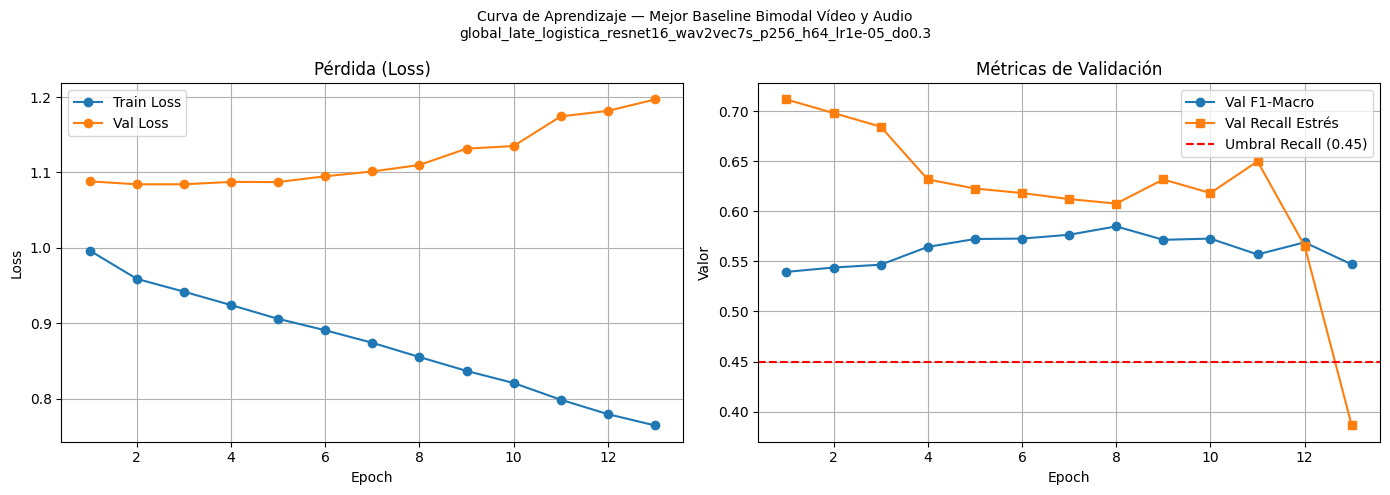

In [15]:
# ----------- MOSTRAMOS LOS RESULTADOS Y LA CURVA DE APRENDIZAJE DEL MEJOR MODELO -----------

mejor_config = "global_late_logistica_resnet16_wav2vec7s_p256_h64_lr1e-05_do0.3"

if mejor_config is not None:

    json_mejor = f"resultados/bimodales/dev/historial_estres_{mejor_config}.json"
    with open(json_mejor, 'r') as f:
        historial_mejor = json.load(f)

    print(f"\nMEJOR CONFIGURACIÓN FINAL: {mejor_config}")
    print(f"Mejor Val F1: {max(historial_mejor['val_f1']):.4f}")

    epochs_range = range(1, len(historial_mejor['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Curva de Aprendizaje — Mejor Baseline Bimodal Vídeo y Audio\n{mejor_config}", fontsize=10)

    # --- Subplot 1: Train Loss vs Val Loss ---
    axes[0].plot(epochs_range, historial_mejor['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(epochs_range, historial_mejor['val_loss'], label='Val Loss', marker='o')
    axes[0].set_title('Pérdida (Loss)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # --- Subplot 2: Val F1-Macro vs Val Recall Estrés ---
    axes[1].plot(epochs_range, historial_mejor['val_f1'], label='Val F1-Macro', marker='o')
    axes[1].plot(epochs_range, historial_mejor['val_recall_estres'],label='Val Recall Estrés', marker='s')
    axes[1].axhline(y=RECALL_ESTRES_MINIMO, color='red', linestyle='--', label=f'Umbral Recall ({RECALL_ESTRES_MINIMO})')
    axes[1].set_title('Métricas de Validación')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Valor')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(f"Fig_curva_aprendizaje_baseline_bimodal_video_audio.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No se encontró ningún modelo que superara el filtro de Recall mínimo.")

------
### **Baseline de Vídeo y Texto**

* **Fusión Temprana**:
    * **FASE 1**:

In [16]:
#-------------------------- Ventanas a ajustar ------------------------

VENTANAS_VIDEO = [32, 16]
VENTANAS_TEXTO = ['roberta64', 'roberta32']

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'
lr = 1e-4
do = 0.5
h_mlp = 128
prj_dim = 512

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for video_frames in VENTANAS_VIDEO:
    for text_model in VENTANAS_TEXTO:

        nombre_base = (f"global_early_{VIDEO_BACKBONE}{video_frames}_{text_model}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
        pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
        json_path = f"historial_estres_{nombre_base}.json"

        comando = (f"python train.py "
                    f"--train_dataset global "
                    f"--fusion early "
                    f"--video {VIDEO_BACKBONE} "
                    f"--video_frames {video_frames} "
                    f"--text {text_model} ")
                        
        os.system(comando)

        # Extraemos ambas métricas del historial:
        val_f1 = 0.0
        val_recall = 0.0
            
        if os.path.exists(json_path):
            with open(json_path, 'r') as f:
                historial = json.load(f)
                
            # Buscamos el índice de la época con el mejor F1
            mejores_f1_lista = historial['val_f1']
            if mejores_f1_lista:
                mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                val_f1 = historial['val_f1'][mejor_indice]
                val_recall = historial['val_recall_estres'][mejor_indice]

        print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

        # Doble criterio: filtro de recall + selección por F1-Macro
        supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
        mejora_f1 = val_f1 > mejor_f1

        if supera_filtro and mejora_f1:
            # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
            if mejor_config is not None:
                for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

            mejor_f1 = val_f1
            mejor_config = nombre_base
            print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
        else :
            if not supera_filtro:
                print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
            for archivo in [pth_path, json_path]:
                if os.path.exists(archivo):
                    os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: EARLY
--> Vídeo: resnet (32 frames) -> EMBEDDINGS_VISUAL
--> Texto: roberta64 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 453/453 [00:10<00:00, 42.36it/s, loss=1.02] 


Epoch 1. Train Loss: 0.9444. Val Loss: 0.9732. Val F1 Macro: 0.5816. Val Recall Estrés: 0.8160

Nuevo mejor modelo: (F1: 0.5816) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 453/453 [00:08<00:00, 51.15it/s, loss=0.759]


Epoch 2. Train Loss: 0.8377. Val Loss: 0.9248. Val F1 Macro: 0.6210. Val Recall Estrés: 0.7964

Nuevo mejor modelo: (F1: 0.6210) -> Guardando pesos...


...

Epoch 6. Train Loss: 0.7348. Val Loss: 0.9247. Val F1 Macro: 0.6776. Val Recall Estrés: 0.7210

Sin mejora en F1-Score. Límite: 3/5


Epoch 7/20: 100%|██████████| 453/453 [00:08<00:00, 55.57it/s, loss=0.606]


Epoch 7. Train Loss: 0.6988. Val Loss: 0.9599. Val F1 Macro: 0.6812. Val Recall Estrés: 0.6712

Sin mejora en F1-Score. Límite: 4/5


Epoch 8/20: 100%|██████████| 453/453 [00:08<00:00, 55.76it/s, loss=0.867]


Epoch 8. Train Loss: 0.6773. Val Loss: 0.9191. Val F1 Macro: 0.6679. Val Recall Estrés: 0.7466

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 8 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_global_early_resnet16_roberta32_p512_h128_lr0.0001_do0.5.pth
Historial de entrenamiento guardado en: ./historial_estres_global_early_resnet16_roberta32_p512_h128_lr0.0001_do0.5.json
global_early_resnet16_roberta32_p512_h128_lr0.0001_do0.5 --> F1: 0.6880 | Recall estrés: 0.7330

CONFIGURACIÓN GANADORA: global_early_resnet32_roberta64_p512_h128_lr0.0001_do0.5
Mejor Val F1: 0.7022


Las ventanas óptimas obtenidas son de **32 frames** para vídeo y **64 tokens** para texto. 

* **FASE 2**:

In [17]:
#-------------------------- Hiperparámetros a ajustar ------------------------

confg_arq = [(512,128), (256,64)]
LRS = [1e-4,5e-5,1e-5]
dropouts = [0.5, 0.3]

# ------------------------ Valores ya ajustados ------------------------

VENTANA_VIDEO = 32
VENTANA_TEXTO = 'roberta64'

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for prj_dim, h_mlp in confg_arq:
    for lr in LRS:
        for do in dropouts:

            nombre_base = (f"global_early_{VIDEO_BACKBONE}{VENTANA_VIDEO}_{VENTANA_TEXTO}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
            pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
            json_path = f"historial_estres_{nombre_base}.json"

            comando = (f"python train.py "
                       f"--train_dataset global "
                       f"--fusion early "
                       f"--video {VIDEO_BACKBONE} "
                       f"--video_frames {VENTANA_VIDEO} "
                       f"--text {VENTANA_TEXTO} "
                       f"--proj_dim {prj_dim} "
                       f"--hidden_mlp {h_mlp} "
                       f"--lr {lr} "
                       f"--dropout {do} ")
                        
            os.system(comando)

            # Extraemos ambas métricas del historial:
            val_f1 = 0.0
            val_recall = 0.0
            
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    historial = json.load(f)
                
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]

            print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

            # Doble criterio: filtro de recall + selección por F1-Macro
            supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
            mejora_f1 = val_f1 > mejor_f1

            if supera_filtro and mejora_f1:
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None:
                    for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                        if os.path.exists(archivo):
                            os.remove(archivo)

                mejor_f1 = val_f1
                mejor_config = nombre_base
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
            else :
                if not supera_filtro:
                    print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
                for archivo in [pth_path, json_path]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: EARLY
--> Vídeo: resnet (32 frames) -> EMBEDDINGS_VISUAL
--> Texto: roberta64 -> EMBEDDINGS_TEXTO


Epoch 2/20:   1%|          | 5/453 [00:00<00:09, 48.78it/s, loss=0.965]

Epoch 1. Train Loss: 0.9431. Val Loss: 0.9673. Val F1 Macro: 0.5799. Val Recall Estrés: 0.8175

Nuevo mejor modelo: (F1: 0.5799) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 453/453 [00:08<00:00, 53.31it/s, loss=0.672]


Epoch 2. Train Loss: 0.8484. Val Loss: 0.9450. Val F1 Macro: 0.6074. Val Recall Estrés: 0.8115

Nuevo mejor modelo: (F1: 0.6074) -> Guardando pesos...


...

Epoch 17. Train Loss: 0.6292. Val Loss: 0.9575. Val F1 Macro: 0.6210. Val Recall Estrés: 0.7557

Sin mejora en F1-Score. Límite: 3/5


Epoch 18/20: 100%|██████████| 453/453 [00:08<00:00, 52.87it/s, loss=0.64] 


Epoch 18. Train Loss: 0.6071. Val Loss: 0.9756. Val F1 Macro: 0.6235. Val Recall Estrés: 0.7210

Sin mejora en F1-Score. Límite: 4/5


Epoch 19/20: 100%|██████████| 453/453 [00:08<00:00, 54.13it/s, loss=0.644]


Epoch 19. Train Loss: 0.5920. Val Loss: 1.0209. Val F1 Macro: 0.6465. Val Recall Estrés: 0.6154

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 19 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_global_early_resnet32_roberta64_p256_h64_lr1e-05_do0.3.pth
Historial de entrenamiento guardado en: ./historial_estres_global_early_resnet32_roberta64_p256_h64_lr1e-05_do0.3.json
global_early_resnet32_roberta64_p256_h64_lr1e-05_do0.3 --> F1: 0.6603 | Recall estrés: 0.6003

CONFIGURACIÓN GANADORA: global_early_resnet32_roberta64_p512_h128_lr0.0001_do0.3
Mejor Val F1: 0.7184


El modelo bimodal de **vídeo** y **texto** alcanza en fusión temprana un rendimiento de F1 Score =0.7184 y Recall=0.6275

* **Fusión Tardía mediante voto mayoritario**:
    * **FASE 1**:

In [18]:
#-------------------------- Ventanas a ajustar ------------------------

VENTANAS_VIDEO = [32, 16]
VENTANAS_TEXTO = ['roberta64', 'roberta32']

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'
lr = 1e-4
do = 0.5
h_mlp = 128
prj_dim = 512

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for video_frames in VENTANAS_VIDEO:
    for text_model in VENTANAS_TEXTO:

        nombre_base = (f"global_late_voto_{VIDEO_BACKBONE}{video_frames}_{text_model}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
        pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
        json_path = f"historial_estres_{nombre_base}.json"

        comando = (f"python train.py "
                    f"--train_dataset global "
                    f"--fusion late "
                    f"--late_mode voto "
                    f"--video {VIDEO_BACKBONE} "
                    f"--video_frames {video_frames} "
                    f"--text {text_model} ")
                        
        os.system(comando)

        # Extraemos ambas métricas del historial:
        val_f1 = 0.0
        val_recall = 0.0
            
        if os.path.exists(json_path):
            with open(json_path, 'r') as f:
                historial = json.load(f)
                
            # Buscamos el índice de la época con el mejor F1
            mejores_f1_lista = historial['val_f1']
            if mejores_f1_lista:
                mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                val_f1 = historial['val_f1'][mejor_indice]
                val_recall = historial['val_recall_estres'][mejor_indice]

        print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

        # Doble criterio: filtro de recall + selección por F1-Macro
        supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
        mejora_f1 = val_f1 > mejor_f1

        if supera_filtro and mejora_f1:
            # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
            if mejor_config is not None:
                for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

            mejor_f1 = val_f1
            mejor_config = nombre_base
            print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
        else :
            if not supera_filtro:
                print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
            for archivo in [pth_path, json_path]:
                if os.path.exists(archivo):
                    os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: LATE
--> Vídeo: resnet (32 frames) -> EMBEDDINGS_VISUAL
--> Texto: roberta64 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 453/453 [00:09<00:00, 47.69it/s, loss=0.979]


Epoch 1. Train Loss: 0.9855. Val Loss: 1.0172. Val F1 Macro: 0.6267. Val Recall Estrés: 0.7044

Nuevo mejor modelo: (F1: 0.6267) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 453/453 [00:09<00:00, 45.50it/s, loss=1.09] 


Epoch 2. Train Loss: 0.9315. Val Loss: 0.9980. Val F1 Macro: 0.6520. Val Recall Estrés: 0.6817

Nuevo mejor modelo: (F1: 0.6520) -> Guardando pesos...


...

Epoch 9. Train Loss: 0.8294. Val Loss: 0.9590. Val F1 Macro: 0.6634. Val Recall Estrés: 0.7511

Sin mejora en F1-Score. Límite: 3/5


Epoch 10/20: 100%|██████████| 453/453 [00:09<00:00, 49.26it/s, loss=0.887]


Epoch 10. Train Loss: 0.8127. Val Loss: 1.0003. Val F1 Macro: 0.6367. Val Recall Estrés: 0.7149

Sin mejora en F1-Score. Límite: 4/5


Epoch 11/20: 100%|██████████| 453/453 [00:09<00:00, 49.26it/s, loss=1.38] 


Epoch 11. Train Loss: 0.8071. Val Loss: 0.9962. Val F1 Macro: 0.6726. Val Recall Estrés: 0.6305

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 11 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_global_late_voto_resnet16_roberta32_p512_h128_lr0.0001_do0.5.pth
Historial de entrenamiento guardado en: ./historial_estres_global_late_voto_resnet16_roberta32_p512_h128_lr0.0001_do0.5.json
global_late_voto_resnet16_roberta32_p512_h128_lr0.0001_do0.5 --> F1: 0.6945 | Recall estrés: 0.7044

CONFIGURACIÓN GANADORA: global_late_voto_resnet32_roberta64_p512_h128_lr0.0001_do0.5
Mejor Val F1: 0.7093


Las ventanas óptimas son de **32 frames** en vídeo y de **64 tokens** en audio. 

* **FASE 2**:

In [19]:
#-------------------------- Hiperparámetros a ajustar ------------------------

confg_arq = [(512,128), (256,64)]
LRS = [1e-4,5e-5,1e-5]
dropouts = [0.5, 0.3]

# ------------------------ Valores ya ajustados ------------------------

VENTANA_VIDEO = 32
VENTANA_TEXTO = 'roberta64'

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for prj_dim, h_mlp in confg_arq:
    for lr in LRS:
        for do in dropouts:

            nombre_base = (f"global_late_voto_{VIDEO_BACKBONE}{VENTANA_VIDEO}_{VENTANA_TEXTO}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
            pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
            json_path = f"historial_estres_{nombre_base}.json"

            comando = (f"python train.py "
                       f"--train_dataset global "
                       f"--fusion late "
                       f"--late_mode voto "
                       f"--video {VIDEO_BACKBONE} "
                       f"--video_frames {VENTANA_VIDEO} "
                       f"--text {VENTANA_TEXTO} "
                       f"--proj_dim {prj_dim} "
                       f"--hidden_mlp {h_mlp} "
                       f"--lr {lr} "
                       f"--dropout {do} ")
                        
            os.system(comando)

            # Extraemos ambas métricas del historial:
            val_f1 = 0.0
            val_recall = 0.0
            
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    historial = json.load(f)
                
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]

            print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

            # Doble criterio: filtro de recall + selección por F1-Macro
            supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
            mejora_f1 = val_f1 > mejor_f1

            if supera_filtro and mejora_f1:
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None:
                    for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                        if os.path.exists(archivo):
                            os.remove(archivo)

                mejor_f1 = val_f1
                mejor_config = nombre_base
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
            else :
                if not supera_filtro:
                    print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
                for archivo in [pth_path, json_path]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: LATE
--> Vídeo: resnet (32 frames) -> EMBEDDINGS_VISUAL
--> Texto: roberta64 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 453/453 [00:09<00:00, 49.21it/s, loss=0.976]


Epoch 1. Train Loss: 0.9848. Val Loss: 1.0048. Val F1 Macro: 0.6310. Val Recall Estrés: 0.7345

Nuevo mejor modelo: (F1: 0.6310) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 453/453 [00:08<00:00, 51.10it/s, loss=0.847]


Epoch 2. Train Loss: 0.9383. Val Loss: 0.9962. Val F1 Macro: 0.6516. Val Recall Estrés: 0.6863

Nuevo mejor modelo: (F1: 0.6516) -> Guardando pesos...


...

Epoch 16. Train Loss: 0.8040. Val Loss: 0.9995. Val F1 Macro: 0.6596. Val Recall Estrés: 0.6682

Sin mejora en F1-Score. Límite: 3/5


Epoch 17/20: 100%|██████████| 453/453 [00:09<00:00, 48.15it/s, loss=0.749]


Epoch 17. Train Loss: 0.7939. Val Loss: 1.0180. Val F1 Macro: 0.6584. Val Recall Estrés: 0.6184

Sin mejora en F1-Score. Límite: 4/5


Epoch 18/20: 100%|██████████| 453/453 [00:09<00:00, 47.42it/s, loss=0.891]


Epoch 18. Train Loss: 0.7863. Val Loss: 1.0588. Val F1 Macro: 0.6444. Val Recall Estrés: 0.5370

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 18 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_global_late_voto_resnet32_roberta64_p256_h64_lr1e-05_do0.3.pth
Historial de entrenamiento guardado en: ./historial_estres_global_late_voto_resnet32_roberta64_p256_h64_lr1e-05_do0.3.json
global_late_voto_resnet32_roberta64_p256_h64_lr1e-05_do0.3 --> F1: 0.6660 | Recall estrés: 0.5882

CONFIGURACIÓN GANADORA: global_late_voto_resnet32_roberta64_p512_h128_lr0.0001_do0.5
Mejor Val F1: 0.7031


El baseline bimodal de **vídeo** y **texto** para la fusión tardía mediante voto mayoritario alcanza un rendimiento de F1 Macro =0.7031 y Recall=0.6094

* **Fusión Tardía mediante promedio**:
    * **FASE 1**:

In [4]:
#-------------------------- Ventanas a ajustar ------------------------

VENTANAS_VIDEO = [32, 16]
VENTANAS_TEXTO = ['roberta64', 'roberta32']

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'
lr = 1e-4
do = 0.5
h_mlp = 128
prj_dim = 512

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for video_frames in VENTANAS_VIDEO:
    for text_model in VENTANAS_TEXTO:

        nombre_base = (f"global_late_promedio_{VIDEO_BACKBONE}{video_frames}_{text_model}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
        pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
        json_path = f"historial_estres_{nombre_base}.json"

        comando = (f"python train.py "
                    f"--train_dataset global "
                    f"--fusion late "
                    f"--late_mode promedio "
                    f"--video {VIDEO_BACKBONE} "
                    f"--video_frames {video_frames} "
                    f"--text {text_model} ")
                        
        os.system(comando)

        # Extraemos ambas métricas del historial:
        val_f1 = 0.0
        val_recall = 0.0
            
        if os.path.exists(json_path):
            with open(json_path, 'r') as f:
                historial = json.load(f)
                
            # Buscamos el índice de la época con el mejor F1
            mejores_f1_lista = historial['val_f1']
            if mejores_f1_lista:
                mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                val_f1 = historial['val_f1'][mejor_indice]
                val_recall = historial['val_recall_estres'][mejor_indice]

        print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

        # Doble criterio: filtro de recall + selección por F1-Macro
        supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
        mejora_f1 = val_f1 > mejor_f1

        if supera_filtro and mejora_f1:
            # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
            if mejor_config is not None:
                for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

            mejor_f1 = val_f1
            mejor_config = nombre_base
            print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
        else :
            if not supera_filtro:
                print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
            for archivo in [pth_path, json_path]:
                if os.path.exists(archivo):
                    os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: LATE
--> Vídeo: resnet (32 frames) -> EMBEDDINGS_VISUAL
--> Texto: roberta64 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 453/453 [00:09<00:00, 48.41it/s, loss=1.36] 


Epoch 1. Train Loss: 0.8942. Val Loss: 0.9694. Val F1 Macro: 0.5918. Val Recall Estrés: 0.8084

Nuevo mejor modelo: (F1: 0.5918) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 453/453 [00:08<00:00, 55.78it/s, loss=0.729]


Epoch 2. Train Loss: 0.8158. Val Loss: 0.9364. Val F1 Macro: 0.6426. Val Recall Estrés: 0.6923

Nuevo mejor modelo: (F1: 0.6426) -> Guardando pesos...


...

Epoch 15. Train Loss: 0.5013. Val Loss: 0.9716. Val F1 Macro: 0.6716. Val Recall Estrés: 0.7360

Sin mejora en F1-Score. Límite: 3/5


Epoch 16/20: 100%|██████████| 453/453 [00:08<00:00, 55.43it/s, loss=1.16] 


Epoch 16. Train Loss: 0.4838. Val Loss: 1.4013. Val F1 Macro: 0.6365. Val Recall Estrés: 0.3771

Sin mejora en F1-Score. Límite: 4/5


Epoch 17/20: 100%|██████████| 453/453 [00:08<00:00, 56.22it/s, loss=0.62] 


Epoch 17. Train Loss: 0.4627. Val Loss: 1.2472. Val F1 Macro: 0.6748. Val Recall Estrés: 0.5023

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 17 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_global_late_promedio_resnet16_roberta32_p512_h128_lr0.0001_do0.5.pth
Historial de entrenamiento guardado en: ./historial_estres_global_late_promedio_resnet16_roberta32_p512_h128_lr0.0001_do0.5.json
global_late_promedio_resnet16_roberta32_p512_h128_lr0.0001_do0.5 --> F1: 0.6813 | Recall estrés: 0.6244

CONFIGURACIÓN GANADORA: global_late_promedio_resnet32_roberta64_p512_h128_lr0.0001_do0.5
Mejor Val F1: 0.7023


Las ventanas óptimas para **vídeo** y **texto** en fusión tardía mediante promedio son **32 frames** y **64 tokens** respectivamente. 

* **FASE 2**:

In [5]:
#-------------------------- Hiperparámetros a ajustar ------------------------

confg_arq = [(512,128), (256,64)]
LRS = [1e-4,5e-5,1e-5]
dropouts = [0.5, 0.3]

# ------------------------ Valores ya ajustados ------------------------

VENTANA_VIDEO = 32
VENTANA_TEXTO = 'roberta64'

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for prj_dim, h_mlp in confg_arq:
    for lr in LRS:
        for do in dropouts:

            nombre_base = (f"global_late_promedio_{VIDEO_BACKBONE}{VENTANA_VIDEO}_{VENTANA_TEXTO}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
            pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
            json_path = f"historial_estres_{nombre_base}.json"

            comando = (f"python train.py "
                       f"--train_dataset global "
                       f"--fusion late "
                       f"--late_mode promedio "
                       f"--video {VIDEO_BACKBONE} "
                       f"--video_frames {VENTANA_VIDEO} "
                       f"--text {VENTANA_TEXTO} "
                       f"--proj_dim {prj_dim} "
                       f"--hidden_mlp {h_mlp} "
                       f"--lr {lr} "
                       f"--dropout {do} ")
                        
            os.system(comando)

            # Extraemos ambas métricas del historial:
            val_f1 = 0.0
            val_recall = 0.0
            
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    historial = json.load(f)
                
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]

            print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

            # Doble criterio: filtro de recall + selección por F1-Macro
            supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
            mejora_f1 = val_f1 > mejor_f1

            if supera_filtro and mejora_f1:
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None:
                    for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                        if os.path.exists(archivo):
                            os.remove(archivo)

                mejor_f1 = val_f1
                mejor_config = nombre_base
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
            else :
                if not supera_filtro:
                    print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
                for archivo in [pth_path, json_path]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: LATE
--> Vídeo: resnet (32 frames) -> EMBEDDINGS_VISUAL
--> Texto: roberta64 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 453/453 [00:09<00:00, 48.11it/s, loss=0.688]


Epoch 1. Train Loss: 0.8956. Val Loss: 0.9473. Val F1 Macro: 0.6151. Val Recall Estrés: 0.7934

Nuevo mejor modelo: (F1: 0.6151) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 453/453 [00:08<00:00, 50.47it/s, loss=0.758]


Epoch 2. Train Loss: 0.8112. Val Loss: 0.9601. Val F1 Macro: 0.6659. Val Recall Estrés: 0.6305

Nuevo mejor modelo: (F1: 0.6659) -> Guardando pesos...


...

Epoch 10. Train Loss: 0.7123. Val Loss: 1.0130. Val F1 Macro: 0.5862. Val Recall Estrés: 0.7707

Sin mejora en F1-Score. Límite: 3/5


Epoch 12/20:   1%|▏         | 6/453 [00:00<00:08, 54.86it/s, loss=0.678]

Epoch 11. Train Loss: 0.6988. Val Loss: 0.9987. Val F1 Macro: 0.5947. Val Recall Estrés: 0.7526

Sin mejora en F1-Score. Límite: 4/5


Epoch 12/20: 100%|██████████| 453/453 [00:08<00:00, 54.27it/s, loss=0.767]


Epoch 12. Train Loss: 0.6758. Val Loss: 1.0297. Val F1 Macro: 0.5984. Val Recall Estrés: 0.7195

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 12 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_global_late_promedio_resnet32_roberta64_p256_h64_lr1e-05_do0.3.pth
Historial de entrenamiento guardado en: ./historial_estres_global_late_promedio_resnet32_roberta64_p256_h64_lr1e-05_do0.3.json
global_late_promedio_resnet32_roberta64_p256_h64_lr1e-05_do0.3 --> F1: 0.6212 | Recall estrés: 0.7345

CONFIGURACIÓN GANADORA: global_late_promedio_resnet32_roberta64_p512_h128_lr0.0001_do0.3
Mejor Val F1: 0.7093


La fusión tardía mediante promedio alcanza un rendimiento tras el ajuste para **vídeo** y **texto** de F1 Macro=0.7093 y Recall=0.6109

* **Fusión Tardía mediante aproximación a Regresión Logística**:
    * **FASE 1**:

In [6]:
#-------------------------- Ventanas a ajustar ------------------------

VENTANAS_VIDEO = [32, 16]
VENTANAS_TEXTO = ['roberta64', 'roberta32']

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'
lr = 1e-4
do = 0.5
h_mlp = 128
prj_dim = 512

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for video_frames in VENTANAS_VIDEO:
    for text_model in VENTANAS_TEXTO:

        nombre_base = (f"global_late_logistica_{VIDEO_BACKBONE}{video_frames}_{text_model}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
        pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
        json_path = f"historial_estres_{nombre_base}.json"

        comando = (f"python train.py "
                    f"--train_dataset global "
                    f"--fusion late "
                    f"--late_mode logistica "
                    f"--video {VIDEO_BACKBONE} "
                    f"--video_frames {video_frames} "
                    f"--text {text_model} ")
                        
        os.system(comando)

        # Extraemos ambas métricas del historial:
        val_f1 = 0.0
        val_recall = 0.0
            
        if os.path.exists(json_path):
            with open(json_path, 'r') as f:
                historial = json.load(f)
                
            # Buscamos el índice de la época con el mejor F1
            mejores_f1_lista = historial['val_f1']
            if mejores_f1_lista:
                mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                val_f1 = historial['val_f1'][mejor_indice]
                val_recall = historial['val_recall_estres'][mejor_indice]

        print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

        # Doble criterio: filtro de recall + selección por F1-Macro
        supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
        mejora_f1 = val_f1 > mejor_f1

        if supera_filtro and mejora_f1:
            # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
            if mejor_config is not None:
                for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

            mejor_f1 = val_f1
            mejor_config = nombre_base
            print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
        else :
            if not supera_filtro:
                print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
            for archivo in [pth_path, json_path]:
                if os.path.exists(archivo):
                    os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: LATE
--> Vídeo: resnet (32 frames) -> EMBEDDINGS_VISUAL
--> Texto: roberta64 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 453/453 [00:10<00:00, 44.46it/s, loss=0.739]


Epoch 1. Train Loss: 0.9413. Val Loss: 1.0260. Val F1 Macro: 0.6016. Val Recall Estrés: 0.6652

Nuevo mejor modelo: (F1: 0.6016) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 453/453 [00:08<00:00, 53.98it/s, loss=0.696]


Epoch 2. Train Loss: 0.8344. Val Loss: 0.9860. Val F1 Macro: 0.6100. Val Recall Estrés: 0.7376

Nuevo mejor modelo: (F1: 0.6100) -> Guardando pesos...


...

Epoch 18. Train Loss: 0.4501. Val Loss: 1.1865. Val F1 Macro: 0.6793. Val Recall Estrés: 0.5596

Sin mejora en F1-Score. Límite: 2/5


Epoch 19/20: 100%|██████████| 453/453 [00:08<00:00, 55.94it/s, loss=0.267]


Epoch 19. Train Loss: 0.4133. Val Loss: 1.1333. Val F1 Macro: 0.6977. Val Recall Estrés: 0.6078

Nuevo mejor modelo: (F1: 0.6977) -> Guardando pesos...


Epoch 20/20: 100%|██████████| 453/453 [00:08<00:00, 54.22it/s, loss=0.266]


Epoch 20. Train Loss: 0.4045. Val Loss: 1.1471. Val F1 Macro: 0.6870. Val Recall Estrés: 0.6667

Sin mejora en F1-Score. Límite: 1/5
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_global_late_logistica_resnet16_roberta32_p512_h128_lr0.0001_do0.5.pth
Historial de entrenamiento guardado en: ./historial_estres_global_late_logistica_resnet16_roberta32_p512_h128_lr0.0001_do0.5.json
global_late_logistica_resnet16_roberta32_p512_h128_lr0.0001_do0.5 --> F1: 0.6977 | Recall estrés: 0.6078

CONFIGURACIÓN GANADORA: global_late_logistica_resnet32_roberta64_p512_h128_lr0.0001_do0.5
Mejor Val F1: 0.7107


Las ventanas óptimas son de **32 frames** en vídeo y **64 tokens** en texto. 

* **FASE 2**:

In [7]:
#-------------------------- Hiperparámetros a ajustar ------------------------

confg_arq = [(512,128), (256,64)]
LRS = [1e-4,5e-5,1e-5]
dropouts = [0.5, 0.3]

# ------------------------ Valores ya ajustados ------------------------

VENTANA_VIDEO = 32
VENTANA_TEXTO = 'roberta64'

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet' 

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for prj_dim, h_mlp in confg_arq:
    for lr in LRS:
        for do in dropouts:

            nombre_base = (f"global_late_logistica_{VIDEO_BACKBONE}{VENTANA_VIDEO}_{VENTANA_TEXTO}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
            pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
            json_path = f"historial_estres_{nombre_base}.json"

            comando = (f"python train.py "
                       f"--train_dataset global "
                       f"--fusion late "
                       f"--late_mode logistica "
                       f"--video {VIDEO_BACKBONE} "
                       f"--video_frames {VENTANA_VIDEO} "
                       f"--text {VENTANA_TEXTO} "
                       f"--proj_dim {prj_dim} "
                       f"--hidden_mlp {h_mlp} "
                       f"--lr {lr} "
                       f"--dropout {do} ")
                        
            os.system(comando)

            # Extraemos ambas métricas del historial:
            val_f1 = 0.0
            val_recall = 0.0
            
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    historial = json.load(f)
                
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]

            print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

            # Doble criterio: filtro de recall + selección por F1-Macro
            supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
            mejora_f1 = val_f1 > mejor_f1

            if supera_filtro and mejora_f1:
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None:
                    for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                        if os.path.exists(archivo):
                            os.remove(archivo)

                mejor_f1 = val_f1
                mejor_config = nombre_base
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
            else :
                if not supera_filtro:
                    print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
                for archivo in [pth_path, json_path]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: LATE
--> Vídeo: resnet (32 frames) -> EMBEDDINGS_VISUAL
--> Texto: roberta64 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 453/453 [00:09<00:00, 47.17it/s, loss=0.532]


Epoch 1. Train Loss: 0.8976. Val Loss: 0.9729. Val F1 Macro: 0.5763. Val Recall Estrés: 0.8084

Nuevo mejor modelo: (F1: 0.5763) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 453/453 [00:08<00:00, 52.81it/s, loss=0.772]


Epoch 2. Train Loss: 0.8116. Val Loss: 0.9481. Val F1 Macro: 0.6186. Val Recall Estrés: 0.7783

Nuevo mejor modelo: (F1: 0.6186) -> Guardando pesos...


...

Epoch 16. Train Loss: 0.6598. Val Loss: 1.1323. Val F1 Macro: 0.5639. Val Recall Estrés: 0.7949

Sin mejora en F1-Score. Límite: 3/5


Epoch 17/20: 100%|██████████| 453/453 [00:08<00:00, 54.74it/s, loss=0.724]


Epoch 17. Train Loss: 0.6411. Val Loss: 1.0964. Val F1 Macro: 0.5812. Val Recall Estrés: 0.7391

Sin mejora en F1-Score. Límite: 4/5


Epoch 18/20: 100%|██████████| 453/453 [00:09<00:00, 49.32it/s, loss=0.878]


Epoch 18. Train Loss: 0.6151. Val Loss: 1.1682. Val F1 Macro: 0.5458. Val Recall Estrés: 0.8190

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 18 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_global_late_logistica_resnet32_roberta64_p256_h64_lr1e-05_do0.3.pth
Historial de entrenamiento guardado en: ./historial_estres_global_late_logistica_resnet32_roberta64_p256_h64_lr1e-05_do0.3.json
global_late_logistica_resnet32_roberta64_p256_h64_lr1e-05_do0.3 --> F1: 0.5881 | Recall estrés: 0.7602

CONFIGURACIÓN GANADORA: global_late_logistica_resnet32_roberta64_p512_h128_lr0.0001_do0.5
Mejor Val F1: 0.7215


El mejor modelo bimodal de fusión tardía mediante regresión logística alcanza un rendimiento en **vídeo** y **texto** alcanza un rendimiento de F1 Macro=0.7215 y Recall=0.5505

* **Fusión mediante Atención**:
    * **FASE 1**:

In [8]:
#-------------------------- Ventanas a ajustar ------------------------

VENTANAS_VIDEO = [32, 16]
VENTANAS_TEXTO = ['roberta64', 'roberta32']

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'
lr = 1e-4
do = 0.5
h_mlp = 128
prj_dim = 512

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for video_frames in VENTANAS_VIDEO:
    for text_model in VENTANAS_TEXTO:

        nombre_base = (f"global_attention_{VIDEO_BACKBONE}{video_frames}_{text_model}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
        pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
        json_path = f"historial_estres_{nombre_base}.json"

        comando = (f"python train.py "
                    f"--train_dataset global "
                    f"--fusion attention "
                    f"--video {VIDEO_BACKBONE} "
                    f"--video_frames {video_frames} "
                    f"--text {text_model} ")
                        
        os.system(comando)

        # Extraemos ambas métricas del historial:
        val_f1 = 0.0
        val_recall = 0.0
            
        if os.path.exists(json_path):
            with open(json_path, 'r') as f:
                historial = json.load(f)
                
            # Buscamos el índice de la época con el mejor F1
            mejores_f1_lista = historial['val_f1']
            if mejores_f1_lista:
                mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                val_f1 = historial['val_f1'][mejor_indice]
                val_recall = historial['val_recall_estres'][mejor_indice]

        print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

        # Doble criterio: filtro de recall + selección por F1-Macro
        supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
        mejora_f1 = val_f1 > mejor_f1

        if supera_filtro and mejora_f1:
            # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
            if mejor_config is not None:
                for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

            mejor_f1 = val_f1
            mejor_config = nombre_base
            print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
        else :
            if not supera_filtro:
                print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
            for archivo in [pth_path, json_path]:
                if os.path.exists(archivo):
                    os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: ATTENTION
--> Vídeo: resnet (32 frames) -> EMBEDDINGS_VISUAL
--> Texto: roberta64 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 453/453 [00:09<00:00, 46.73it/s, loss=0.586]


Epoch 1. Train Loss: 0.9047. Val Loss: 0.9624. Val F1 Macro: 0.5875. Val Recall Estrés: 0.8446

Nuevo mejor modelo: (F1: 0.5875) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 453/453 [00:08<00:00, 51.57it/s, loss=1.09] 


Epoch 2. Train Loss: 0.8182. Val Loss: 0.9040. Val F1 Macro: 0.6503. Val Recall Estrés: 0.7843

Nuevo mejor modelo: (F1: 0.6503) -> Guardando pesos...


...

Epoch 14. Train Loss: 0.5493. Val Loss: 1.0055. Val F1 Macro: 0.6888. Val Recall Estrés: 0.6742

Sin mejora en F1-Score. Límite: 3/5


Epoch 15/20: 100%|██████████| 453/453 [00:08<00:00, 51.13it/s, loss=0.478]


Epoch 15. Train Loss: 0.5337. Val Loss: 0.9527. Val F1 Macro: 0.6864. Val Recall Estrés: 0.7617

Sin mejora en F1-Score. Límite: 4/5


Epoch 16/20: 100%|██████████| 453/453 [00:09<00:00, 50.27it/s, loss=0.636]


Epoch 16. Train Loss: 0.5185. Val Loss: 0.8995. Val F1 Macro: 0.6907. Val Recall Estrés: 0.7617

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 16 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_global_attention_resnet16_roberta32_p512_h128_lr0.0001_do0.5.pth
Historial de entrenamiento guardado en: ./historial_estres_global_attention_resnet16_roberta32_p512_h128_lr0.0001_do0.5.json
global_attention_resnet16_roberta32_p512_h128_lr0.0001_do0.5 --> F1: 0.7060 | Recall estrés: 0.7119

CONFIGURACIÓN GANADORA: global_attention_resnet32_roberta32_p512_h128_lr0.0001_do0.5
Mejor Val F1: 0.7205


Las ventanas óptimas son de **32 frames** para vídeo y **32 tokens** para texto. 

* **FASE 2**:

In [9]:
#-------------------------- Hiperparámetros a ajustar ------------------------

confg_arq = [(512,128), (256,64)]
LRS = [1e-4,5e-5,1e-5]
dropouts = [0.5, 0.3]

# ------------------------ Valores ya ajustados ------------------------

VENTANA_VIDEO = 32
VENTANA_TEXTO = 'roberta32'

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for prj_dim, h_mlp in confg_arq:
    for lr in LRS:
        for do in dropouts:

            nombre_base = (f"global_attention_{VIDEO_BACKBONE}{VENTANA_VIDEO}_{VENTANA_TEXTO}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
            pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
            json_path = f"historial_estres_{nombre_base}.json"

            comando = (f"python train.py "
                       f"--train_dataset global "
                       f"--fusion attention "
                       f"--video {VIDEO_BACKBONE} "
                       f"--video_frames {VENTANA_VIDEO} "
                       f"--text {VENTANA_TEXTO} "
                       f"--proj_dim {prj_dim} "
                       f"--hidden_mlp {h_mlp} "
                       f"--lr {lr} "
                       f"--dropout {do} ")
                        
            os.system(comando)

            # Extraemos ambas métricas del historial:
            val_f1 = 0.0
            val_recall = 0.0
            
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    historial = json.load(f)
                
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]

            print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

            # Doble criterio: filtro de recall + selección por F1-Macro
            supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
            mejora_f1 = val_f1 > mejor_f1

            if supera_filtro and mejora_f1:
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None:
                    for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                        if os.path.exists(archivo):
                            os.remove(archivo)

                mejor_f1 = val_f1
                mejor_config = nombre_base
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
            else :
                if not supera_filtro:
                    print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
                for archivo in [pth_path, json_path]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: ATTENTION
--> Vídeo: resnet (32 frames) -> EMBEDDINGS_VISUAL
--> Texto: roberta32 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 453/453 [00:09<00:00, 46.71it/s, loss=0.879]


Epoch 1. Train Loss: 0.9062. Val Loss: 1.0011. Val F1 Macro: 0.5590. Val Recall Estrés: 0.8190

Nuevo mejor modelo: (F1: 0.5590) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 453/453 [00:08<00:00, 55.09it/s, loss=0.614]


Epoch 2. Train Loss: 0.8265. Val Loss: 0.9498. Val F1 Macro: 0.5906. Val Recall Estrés: 0.8597

Nuevo mejor modelo: (F1: 0.5906) -> Guardando pesos...


...

Epoch 18. Train Loss: 0.5538. Val Loss: 1.0356. Val F1 Macro: 0.6194. Val Recall Estrés: 0.6787

Sin mejora en F1-Score. Límite: 2/5


Epoch 19/20: 100%|██████████| 453/453 [00:08<00:00, 54.40it/s, loss=0.603]


Epoch 19. Train Loss: 0.5375. Val Loss: 1.0830. Val F1 Macro: 0.5996. Val Recall Estrés: 0.6968

Sin mejora en F1-Score. Límite: 3/5


Epoch 20/20: 100%|██████████| 453/453 [00:08<00:00, 54.63it/s, loss=0.382]


Epoch 20. Train Loss: 0.5180. Val Loss: 1.0641. Val F1 Macro: 0.6153. Val Recall Estrés: 0.6063

Sin mejora en F1-Score. Límite: 4/5
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_global_attention_resnet32_roberta32_p256_h64_lr1e-05_do0.3.pth
Historial de entrenamiento guardado en: ./historial_estres_global_attention_resnet32_roberta32_p256_h64_lr1e-05_do0.3.json
global_attention_resnet32_roberta32_p256_h64_lr1e-05_do0.3 --> F1: 0.6199 | Recall estrés: 0.6561

CONFIGURACIÓN GANADORA: global_attention_resnet32_roberta32_p256_h64_lr0.0001_do0.3
Mejor Val F1: 0.7191


El modelo de **vídeo** y **texto**, para la técnica de fusión mediante atención, alcanza un rendimiento de F1 Macro=0.7191 y Recall=0.5581

Tras ejecutar todos los entrenamiento para todas las técnicas y realizar el ajuste en cada uno de ellos, la técnica de fusión que mayor rendimiento alcanza en **F1-Score Macro** para **VÍDEO Y TEXTO** es: **Fusión Tardía mediante Regresión Logística** (F1 Macro=0.7215 y Recall=0.5505), con la siguiente configuración: 

* **VENTANAS**:
  * **Vídeo**: 32 frames
  * **Texto**: 64 tokens
* **Capacidad de la Arquitectura, Regularización y Aprendizaje**:
    * **Arquitectura**: `proj_dim` = 512, `hidden_mlp` = 128.
    * **Learning Rate**: `lr` = 0.0001
    * **Dropout**: `do` = 0.5


MEJOR CONFIGURACIÓN FINAL: global_late_logistica_resnet32_roberta64_p512_h128_lr0.0001_do0.5
Mejor Val F1: 0.7215


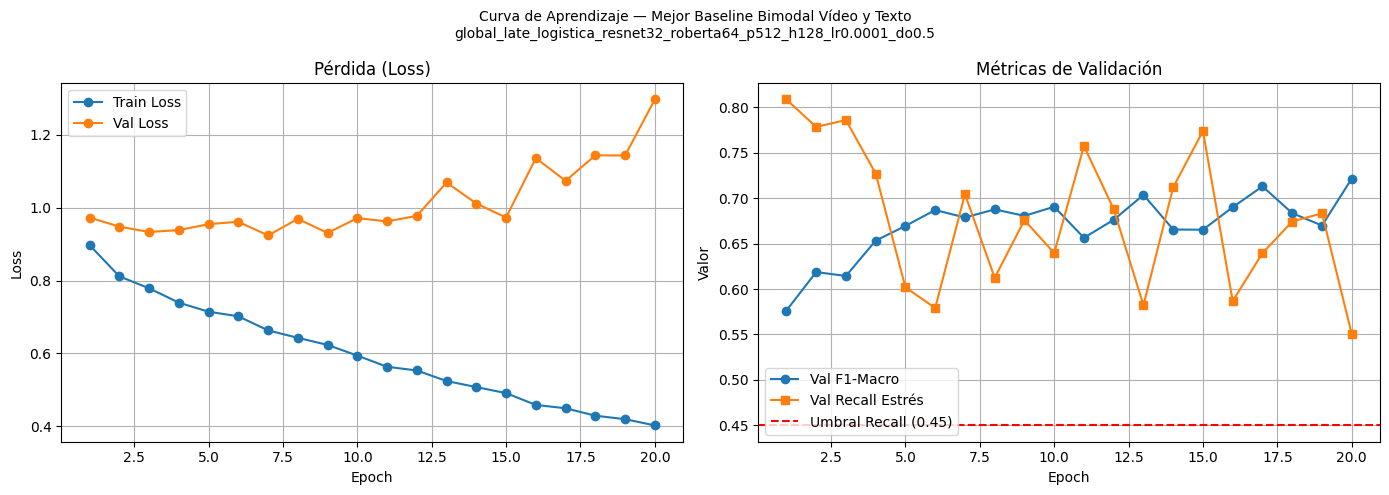

In [10]:
# ----------- MOSTRAMOS LOS RESULTADOS Y LA CURVA DE APRENDIZAJE DEL MEJOR MODELO -----------

mejor_config = "global_late_logistica_resnet32_roberta64_p512_h128_lr0.0001_do0.5"

if mejor_config is not None:

    json_mejor = f"resultados/bimodales/dev/historial_estres_{mejor_config}.json"
    with open(json_mejor, 'r') as f:
        historial_mejor = json.load(f)

    print(f"\nMEJOR CONFIGURACIÓN FINAL: {mejor_config}")
    print(f"Mejor Val F1: {max(historial_mejor['val_f1']):.4f}")

    epochs_range = range(1, len(historial_mejor['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Curva de Aprendizaje — Mejor Baseline Bimodal Vídeo y Texto\n{mejor_config}", fontsize=10)

    # --- Subplot 1: Train Loss vs Val Loss ---
    axes[0].plot(epochs_range, historial_mejor['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(epochs_range, historial_mejor['val_loss'], label='Val Loss', marker='o')
    axes[0].set_title('Pérdida (Loss)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # --- Subplot 2: Val F1-Macro vs Val Recall Estrés ---
    axes[1].plot(epochs_range, historial_mejor['val_f1'], label='Val F1-Macro', marker='o')
    axes[1].plot(epochs_range, historial_mejor['val_recall_estres'],label='Val Recall Estrés', marker='s')
    axes[1].axhline(y=RECALL_ESTRES_MINIMO, color='red', linestyle='--', label=f'Umbral Recall ({RECALL_ESTRES_MINIMO})')
    axes[1].set_title('Métricas de Validación')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Valor')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(f"Fig_curva_aprendizaje_baseline_bimodal_video_texto.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No se encontró ningún modelo que superara el filtro de Recall mínimo.")

-----
### **3. Baseline de Audio y Texto**

* **Fusión Temprana**
    * **FASE 1**:

In [12]:
#-------------------------- Ventanas a ajustar ------------------------

VENTANAS_AUDIO = [11, 7]
VENTANAS_TEXTO = ['roberta64', 'roberta32']

# ----------------------- Configuración básica --------------------------

AUDIO_BACKBONE = 'wav2vec'
lr = 1e-4
do = 0.5
h_mlp = 128
prj_dim = 512

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None


for audio_len in VENTANAS_AUDIO:
    for text_model in VENTANAS_TEXTO:

        nombre_base = (f"global_early_{AUDIO_BACKBONE}{audio_len}s_{text_model}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
        pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
        json_path = f"historial_estres_{nombre_base}.json"

        comando = (f"python train.py "
                    f"--train_dataset global "
                    f"--fusion early "
                    f"--audio {AUDIO_BACKBONE} "
                    f"--audio_len {audio_len} "
                    f"--text {text_model} ")
                        
        os.system(comando)

        # Extraemos ambas métricas del historial:
        val_f1 = 0.0
        val_recall = 0.0
            
        if os.path.exists(json_path):
            with open(json_path, 'r') as f:
                historial = json.load(f)
                
            # Buscamos el índice de la época con el mejor F1
            mejores_f1_lista = historial['val_f1']
            if mejores_f1_lista:
                mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                val_f1 = historial['val_f1'][mejor_indice]
                val_recall = historial['val_recall_estres'][mejor_indice]

        print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

        # Doble criterio: filtro de recall + selección por F1-Macro
        supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
        mejora_f1 = val_f1 > mejor_f1

        if supera_filtro and mejora_f1:
            # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
            if mejor_config is not None:
                for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

            mejor_f1 = val_f1
            mejor_config = nombre_base
            print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
        else :
            if not supera_filtro:
                print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
            for archivo in [pth_path, json_path]:
                if os.path.exists(archivo):
                    os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: EARLY
--> Audio: wav2vec (11s -> 550 pasos) -> EMBEDDINGS_AUDIO
--> Texto: roberta64 -> EMBEDDINGS_TEXTO


Epoch 2/20:   0%|          | 2/453 [00:00<00:27, 16.65it/s, loss=1.06] 

Epoch 1. Train Loss: 1.0327. Val Loss: 0.9703. Val F1 Macro: 0.6497. Val Recall Estrés: 0.7421

Nuevo mejor modelo: (F1: 0.6497) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 453/453 [00:25<00:00, 17.90it/s, loss=0.775]


Epoch 2. Train Loss: 0.9445. Val Loss: 0.9344. Val F1 Macro: 0.6540. Val Recall Estrés: 0.7557

Nuevo mejor modelo: (F1: 0.6540) -> Guardando pesos...


...

Epoch 14. Train Loss: 0.7604. Val Loss: 0.8509. Val F1 Macro: 0.6906. Val Recall Estrés: 0.7632

Sin mejora en F1-Score. Límite: 3/5


Epoch 15/20: 100%|██████████| 453/453 [00:19<00:00, 23.12it/s, loss=0.553]


Epoch 15. Train Loss: 0.7593. Val Loss: 0.8800. Val F1 Macro: 0.6992. Val Recall Estrés: 0.7330

Sin mejora en F1-Score. Límite: 4/5


Epoch 16/20: 100%|██████████| 453/453 [00:22<00:00, 20.28it/s, loss=0.604]


Epoch 16. Train Loss: 0.7501. Val Loss: 0.8550. Val F1 Macro: 0.6892. Val Recall Estrés: 0.7934

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 16 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_global_early_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.pth
Historial de entrenamiento guardado en: ./historial_estres_global_early_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.json
global_early_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5 --> F1: 0.7192 | Recall estrés: 0.6048
--> NUEVO MEJOR MODELO (F1=0.7192 | Recall=0.6048): global_early_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5

CONFIGURACIÓN GANADORA: global_early_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5
Mejor Val F1: 0.7192


Las ventanas óptimas son de **7 segundos** en audio y **32 tokens** en texto. 

* **FASE 2**:

In [13]:
#-------------------------- Hiperparámetros a ajustar ------------------------

confg_arq = [(512,128), (256,64)]
LRS = [1e-4,5e-5,1e-5]
dropouts = [0.5, 0.3]

# ------------------------ Valores ya ajustados ------------------------

VENTANA_AUDIO = 7
VENTANA_TEXTO = 'roberta32'

# ----------------------- Configuración básica --------------------------

AUDIO_BACKBONE = 'wav2vec' 

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for prj_dim, h_mlp in confg_arq:
    for lr in LRS:
        for do in dropouts:

            nombre_base = (f"global_early_{AUDIO_BACKBONE}{VENTANA_AUDIO}s_{VENTANA_TEXTO}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
            pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
            json_path = f"historial_estres_{nombre_base}.json"

            comando = (f"python train.py "
                       f"--train_dataset global "
                       f"--fusion early "
                       f"--audio {AUDIO_BACKBONE} "
                       f"--audio_len {VENTANA_AUDIO} "
                       f"--text {VENTANA_TEXTO} "
                       f"--proj_dim {prj_dim} "
                       f"--hidden_mlp {h_mlp} "
                       f"--lr {lr} "
                       f"--dropout {do} ")
                        
            os.system(comando)

            # Extraemos ambas métricas del historial:
            val_f1 = 0.0
            val_recall = 0.0
            
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    historial = json.load(f)
                
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]

            print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

            # Doble criterio: filtro de recall + selección por F1-Macro
            supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
            mejora_f1 = val_f1 > mejor_f1

            if supera_filtro and mejora_f1:
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None:
                    for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                        if os.path.exists(archivo):
                            os.remove(archivo)

                mejor_f1 = val_f1
                mejor_config = nombre_base
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
            else :
                if not supera_filtro:
                    print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
                for archivo in [pth_path, json_path]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: EARLY
--> Audio: wav2vec (7s -> 350 pasos) -> EMBEDDINGS_AUDIO
--> Texto: roberta32 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 453/453 [00:23<00:00, 19.42it/s, loss=0.797]


Epoch 1. Train Loss: 1.0430. Val Loss: 0.9810. Val F1 Macro: 0.6428. Val Recall Estrés: 0.7134

Nuevo mejor modelo: (F1: 0.6428) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 453/453 [00:23<00:00, 19.46it/s, loss=0.689]


Epoch 2. Train Loss: 0.9503. Val Loss: 0.9251. Val F1 Macro: 0.6356. Val Recall Estrés: 0.7783

Sin mejora en F1-Score. Límite: 1/5


...

Epoch 18. Train Loss: 0.8640. Val Loss: 0.8945. Val F1 Macro: 0.6844. Val Recall Estrés: 0.7662

Sin mejora en F1-Score. Límite: 4/5


Epoch 19/20: 100%|██████████| 453/453 [00:18<00:00, 23.99it/s, loss=1.05] 


Epoch 19. Train Loss: 0.8661. Val Loss: 0.8961. Val F1 Macro: 0.6913. Val Recall Estrés: 0.7300

Nuevo mejor modelo: (F1: 0.6913) -> Guardando pesos...


Epoch 20/20: 100%|██████████| 453/453 [00:19<00:00, 23.38it/s, loss=1.12] 


Epoch 20. Train Loss: 0.8538. Val Loss: 0.9010. Val F1 Macro: 0.6893. Val Recall Estrés: 0.7376

Sin mejora en F1-Score. Límite: 1/5
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_global_early_wav2vec7s_roberta32_p256_h64_lr1e-05_do0.3.pth
Historial de entrenamiento guardado en: ./historial_estres_global_early_wav2vec7s_roberta32_p256_h64_lr1e-05_do0.3.json
global_early_wav2vec7s_roberta32_p256_h64_lr1e-05_do0.3 --> F1: 0.6913 | Recall estrés: 0.7300

CONFIGURACIÓN GANADORA: global_early_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.3
Mejor Val F1: 0.7153


El modelo bimodal de **audio** y **texto** alcanza un rendimiento para **fusión temprana** de F1 Macro=0.7153 y Recall=0.6938

* **Fusión Tardía mediante voto mayoritario**:
    * **FASE 1**:

In [14]:
#-------------------------- Ventanas a ajustar ------------------------

VENTANAS_AUDIO = [11, 7]
VENTANAS_TEXTO = ['roberta64', 'roberta32']

# ----------------------- Configuración básica --------------------------

AUDIO_BACKBONE = 'wav2vec'
lr = 1e-4
do = 0.5
h_mlp = 128
prj_dim = 512

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None


for audio_len in VENTANAS_AUDIO:
    for text_model in VENTANAS_TEXTO:

        nombre_base = (f"global_late_voto_{AUDIO_BACKBONE}{audio_len}s_{text_model}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
        pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
        json_path = f"historial_estres_{nombre_base}.json"

        comando = (f"python train.py "
                    f"--train_dataset global "
                    f"--fusion late "
                    f"--late_mode voto "
                    f"--audio {AUDIO_BACKBONE} "
                    f"--audio_len {audio_len} "
                    f"--text {text_model} ")
                        
        os.system(comando)

        # Extraemos ambas métricas del historial:
        val_f1 = 0.0
        val_recall = 0.0
            
        if os.path.exists(json_path):
            with open(json_path, 'r') as f:
                historial = json.load(f)
                
            # Buscamos el índice de la época con el mejor F1
            mejores_f1_lista = historial['val_f1']
            if mejores_f1_lista:
                mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                val_f1 = historial['val_f1'][mejor_indice]
                val_recall = historial['val_recall_estres'][mejor_indice]

        print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

        # Doble criterio: filtro de recall + selección por F1-Macro
        supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
        mejora_f1 = val_f1 > mejor_f1

        if supera_filtro and mejora_f1:
            # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
            if mejor_config is not None:
                for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

            mejor_f1 = val_f1
            mejor_config = nombre_base
            print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
        else :
            if not supera_filtro:
                print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
            for archivo in [pth_path, json_path]:
                if os.path.exists(archivo):
                    os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: LATE
--> Audio: wav2vec (11s -> 550 pasos) -> EMBEDDINGS_AUDIO
--> Texto: roberta64 -> EMBEDDINGS_TEXTO


Epoch 2/20:   0%|          | 2/453 [00:00<00:27, 16.28it/s, loss=1.12]

Epoch 1. Train Loss: 1.0580. Val Loss: 1.0072. Val F1 Macro: 0.6262. Val Recall Estrés: 0.7421

Nuevo mejor modelo: (F1: 0.6262) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 453/453 [00:27<00:00, 16.36it/s, loss=0.781]


Epoch 2. Train Loss: 0.9767. Val Loss: 0.9873. Val F1 Macro: 0.6463. Val Recall Estrés: 0.7406

Nuevo mejor modelo: (F1: 0.6463) -> Guardando pesos...


...

Epoch 13. Train Loss: 0.8449. Val Loss: 0.9272. Val F1 Macro: 0.6987. Val Recall Estrés: 0.7526

Sin mejora en F1-Score. Límite: 3/5


Epoch 14/20: 100%|██████████| 453/453 [00:18<00:00, 25.07it/s, loss=0.644]


Epoch 14. Train Loss: 0.8424. Val Loss: 0.9360. Val F1 Macro: 0.6543. Val Recall Estrés: 0.8175

Sin mejora en F1-Score. Límite: 4/5


Epoch 15/20: 100%|██████████| 453/453 [00:18<00:00, 25.04it/s, loss=0.678]


Epoch 15. Train Loss: 0.8360. Val Loss: 0.9365. Val F1 Macro: 0.6733. Val Recall Estrés: 0.7632

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 15 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_global_late_voto_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.pth
Historial de entrenamiento guardado en: ./historial_estres_global_late_voto_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.json
global_late_voto_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5 --> F1: 0.7092 | Recall estrés: 0.7164

CONFIGURACIÓN GANADORA: global_late_voto_wav2vec11s_roberta64_p512_h128_lr0.0001_do0.5
Mejor Val F1: 0.7164


Las ventanas óptimas son **11 segundos** en audio y **64 tokens** en texto.

* **FASE 2**:

In [15]:
#-------------------------- Hiperparámetros a ajustar ------------------------

confg_arq = [(512,128), (256,64)]
LRS = [1e-4,5e-5,1e-5]
dropouts = [0.5, 0.3]

# ------------------------ Valores ya ajustados ------------------------

VENTANA_AUDIO = 11
VENTANA_TEXTO = 'roberta64'

# ----------------------- Configuración básica --------------------------

AUDIO_BACKBONE = 'wav2vec' 

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for prj_dim, h_mlp in confg_arq:
    for lr in LRS:
        for do in dropouts:

            nombre_base = (f"global_late_voto_{AUDIO_BACKBONE}{VENTANA_AUDIO}s_{VENTANA_TEXTO}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
            pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
            json_path = f"historial_estres_{nombre_base}.json"

            comando = (f"python train.py "
                       f"--train_dataset global "
                       f"--fusion late "
                       f"--late_mode voto "
                       f"--audio {AUDIO_BACKBONE} "
                       f"--audio_len {VENTANA_AUDIO} "
                       f"--text {VENTANA_TEXTO} "
                       f"--proj_dim {prj_dim} "
                       f"--hidden_mlp {h_mlp} "
                       f"--lr {lr} "
                       f"--dropout {do} ")
                        
            os.system(comando)

            # Extraemos ambas métricas del historial:
            val_f1 = 0.0
            val_recall = 0.0
            
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    historial = json.load(f)
                
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]

            print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

            # Doble criterio: filtro de recall + selección por F1-Macro
            supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
            mejora_f1 = val_f1 > mejor_f1

            if supera_filtro and mejora_f1:
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None:
                    for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                        if os.path.exists(archivo):
                            os.remove(archivo)

                mejor_f1 = val_f1
                mejor_config = nombre_base
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
            else :
                if not supera_filtro:
                    print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
                for archivo in [pth_path, json_path]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: LATE
--> Audio: wav2vec (11s -> 550 pasos) -> EMBEDDINGS_AUDIO
--> Texto: roberta64 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 453/453 [00:29<00:00, 15.48it/s, loss=0.974]


Epoch 1. Train Loss: 1.0660. Val Loss: 0.9999. Val F1 Macro: 0.6582. Val Recall Estrés: 0.7074

Nuevo mejor modelo: (F1: 0.6582) -> Guardando pesos...


Epoch 3/20:   0%|          | 2/453 [00:00<00:28, 15.98it/s, loss=0.834]

Epoch 2. Train Loss: 0.9764. Val Loss: 0.9948. Val F1 Macro: 0.5678. Val Recall Estrés: 0.8884

Sin mejora en F1-Score. Límite: 1/5


...

Epoch 18. Train Loss: 0.9223. Val Loss: 0.9650. Val F1 Macro: 0.6692. Val Recall Estrés: 0.7617

Nuevo mejor modelo: (F1: 0.6692) -> Guardando pesos...


Epoch 19/20: 100%|██████████| 453/453 [00:24<00:00, 18.26it/s, loss=0.823]


Epoch 19. Train Loss: 0.9177. Val Loss: 0.9639. Val F1 Macro: 0.6714. Val Recall Estrés: 0.7587

Nuevo mejor modelo: (F1: 0.6714) -> Guardando pesos...


Epoch 20/20: 100%|██████████| 453/453 [00:23<00:00, 19.12it/s, loss=1.01] 


Epoch 20. Train Loss: 0.9123. Val Loss: 0.9556. Val F1 Macro: 0.6692. Val Recall Estrés: 0.7843

Sin mejora en F1-Score. Límite: 1/5
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_global_late_voto_wav2vec11s_roberta64_p256_h64_lr1e-05_do0.3.pth
Historial de entrenamiento guardado en: ./historial_estres_global_late_voto_wav2vec11s_roberta64_p256_h64_lr1e-05_do0.3.json
global_late_voto_wav2vec11s_roberta64_p256_h64_lr1e-05_do0.3 --> F1: 0.6714 | Recall estrés: 0.7587

CONFIGURACIÓN GANADORA: global_late_voto_wav2vec11s_roberta64_p512_h128_lr0.0001_do0.3
Mejor Val F1: 0.7341


El modelo bimodal alcanza en **fusión tardía mediante voto mayoritario** para **audio** y **texto** un rendimiento de F1 Macro =0.7341 y Recall=0.6727

* **Fusión Tardía mediante promedio**:
    * **FASE 1**:
    

In [16]:
#-------------------------- Ventanas a ajustar ------------------------

VENTANAS_AUDIO = [11, 7]
VENTANAS_TEXTO = ['roberta64', 'roberta32']

# ----------------------- Configuración básica --------------------------


AUDIO_BACKBONE = 'wav2vec'
lr = 1e-4
do = 0.5
h_mlp = 128
prj_dim = 512

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None


for audio_len in VENTANAS_AUDIO:
    for text_model in VENTANAS_TEXTO:

        nombre_base = (f"global_late_promedio_{AUDIO_BACKBONE}{audio_len}s_{text_model}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
        pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
        json_path = f"historial_estres_{nombre_base}.json"

        comando = (f"python train.py "
                    f"--train_dataset global "
                    f"--fusion late "
                    f"--late_mode promedio "
                    f"--audio {AUDIO_BACKBONE} "
                    f"--audio_len {audio_len} "
                    f"--text {text_model} ")
                        
        os.system(comando)

        # Extraemos ambas métricas del historial:
        val_f1 = 0.0
        val_recall = 0.0
            
        if os.path.exists(json_path):
            with open(json_path, 'r') as f:
                historial = json.load(f)
                
            # Buscamos el índice de la época con el mejor F1
            mejores_f1_lista = historial['val_f1']
            if mejores_f1_lista:
                mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                val_f1 = historial['val_f1'][mejor_indice]
                val_recall = historial['val_recall_estres'][mejor_indice]

        print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

        # Doble criterio: filtro de recall + selección por F1-Macro
        supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
        mejora_f1 = val_f1 > mejor_f1

        if supera_filtro and mejora_f1:
            # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
            if mejor_config is not None:
                for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

            mejor_f1 = val_f1
            mejor_config = nombre_base
            print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
        else :
            if not supera_filtro:
                print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
            for archivo in [pth_path, json_path]:
                if os.path.exists(archivo):
                    os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: LATE
--> Audio: wav2vec (11s -> 550 pasos) -> EMBEDDINGS_AUDIO
--> Texto: roberta64 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 453/453 [00:31<00:00, 14.34it/s, loss=0.992]


Epoch 1. Train Loss: 0.9956. Val Loss: 0.9607. Val F1 Macro: 0.6539. Val Recall Estrés: 0.7240

Nuevo mejor modelo: (F1: 0.6539) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 453/453 [00:31<00:00, 14.16it/s, loss=1.05] 


Epoch 2. Train Loss: 0.9141. Val Loss: 0.9116. Val F1 Macro: 0.6490. Val Recall Estrés: 0.7783

Sin mejora en F1-Score. Límite: 1/5


...

Epoch 16. Train Loss: 0.7079. Val Loss: 0.8596. Val F1 Macro: 0.6972. Val Recall Estrés: 0.7617

Sin mejora en F1-Score. Límite: 3/5


Epoch 17/20: 100%|██████████| 453/453 [00:20<00:00, 22.63it/s, loss=0.641]


Epoch 17. Train Loss: 0.6945. Val Loss: 0.8464. Val F1 Macro: 0.6890. Val Recall Estrés: 0.7919

Sin mejora en F1-Score. Límite: 4/5


Epoch 18/20: 100%|██████████| 453/453 [00:19<00:00, 23.24it/s, loss=0.705]


Epoch 18. Train Loss: 0.6886. Val Loss: 0.8433. Val F1 Macro: 0.6961. Val Recall Estrés: 0.7707

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 18 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_global_late_promedio_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.pth
Historial de entrenamiento guardado en: ./historial_estres_global_late_promedio_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.json
global_late_promedio_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5 --> F1: 0.7281 | Recall estrés: 0.6787

CONFIGURACIÓN GANADORA: global_late_promedio_wav2vec7s_roberta64_p512_h128_lr0.0001_do0.5
Mejor Val F1: 0.7362


Las ventanas óptimas son de **7 segundos** en audio y **64 tokens** en texto. 

* **FASE 2**:

In [17]:
#-------------------------- Hiperparámetros a ajustar ------------------------

confg_arq = [(512,128), (256,64)]
LRS = [1e-4,5e-5,1e-5]
dropouts = [0.5, 0.3]

# ------------------------ Valores ya ajustados ------------------------

VENTANA_AUDIO = 7
VENTANA_TEXTO = 'roberta64'

# ----------------------- Configuración básica --------------------------

AUDIO_BACKBONE = 'wav2vec' 

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for prj_dim, h_mlp in confg_arq:
    for lr in LRS:
        for do in dropouts:

            nombre_base = (f"global_late_promedio_{AUDIO_BACKBONE}{VENTANA_AUDIO}s_{VENTANA_TEXTO}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
            pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
            json_path = f"historial_estres_{nombre_base}.json"

            comando = (f"python train.py "
                       f"--train_dataset global "
                       f"--fusion late "
                       f"--late_mode promedio "
                       f"--audio {AUDIO_BACKBONE} "
                       f"--audio_len {VENTANA_AUDIO} "
                       f"--text {VENTANA_TEXTO} "
                       f"--proj_dim {prj_dim} "
                       f"--hidden_mlp {h_mlp} "
                       f"--lr {lr} "
                       f"--dropout {do} ")
                        
            os.system(comando)

            # Extraemos ambas métricas del historial:
            val_f1 = 0.0
            val_recall = 0.0
            
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    historial = json.load(f)
                
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]

            print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

            # Doble criterio: filtro de recall + selección por F1-Macro
            supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
            mejora_f1 = val_f1 > mejor_f1

            if supera_filtro and mejora_f1:
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None:
                    for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                        if os.path.exists(archivo):
                            os.remove(archivo)

                mejor_f1 = val_f1
                mejor_config = nombre_base
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
            else :
                if not supera_filtro:
                    print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
                for archivo in [pth_path, json_path]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: LATE
--> Audio: wav2vec (7s -> 350 pasos) -> EMBEDDINGS_AUDIO
--> Texto: roberta64 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 453/453 [00:21<00:00, 20.60it/s, loss=0.921]


Epoch 1. Train Loss: 0.9905. Val Loss: 0.9617. Val F1 Macro: 0.6277. Val Recall Estrés: 0.7526

Nuevo mejor modelo: (F1: 0.6277) -> Guardando pesos...


Epoch 3/20:   1%|          | 3/453 [00:00<00:20, 21.62it/s, loss=0.896]

Epoch 2. Train Loss: 0.9155. Val Loss: 0.9362. Val F1 Macro: 0.6139. Val Recall Estrés: 0.8446

Sin mejora en F1-Score. Límite: 1/5


...

Epoch 18. Train Loss: 0.8518. Val Loss: 0.9023. Val F1 Macro: 0.6608. Val Recall Estrés: 0.8039

Sin mejora en F1-Score. Límite: 2/5


Epoch 19/20: 100%|██████████| 453/453 [00:16<00:00, 27.82it/s, loss=0.921]


Epoch 19. Train Loss: 0.8447. Val Loss: 0.8963. Val F1 Macro: 0.6875. Val Recall Estrés: 0.7873

Nuevo mejor modelo: (F1: 0.6875) -> Guardando pesos...


Epoch 20/20: 100%|██████████| 453/453 [00:16<00:00, 27.84it/s, loss=0.956]


Epoch 20. Train Loss: 0.8435. Val Loss: 0.8960. Val F1 Macro: 0.6563. Val Recall Estrés: 0.8160

Sin mejora en F1-Score. Límite: 1/5
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_global_late_promedio_wav2vec7s_roberta64_p256_h64_lr1e-05_do0.3.pth
Historial de entrenamiento guardado en: ./historial_estres_global_late_promedio_wav2vec7s_roberta64_p256_h64_lr1e-05_do0.3.json
global_late_promedio_wav2vec7s_roberta64_p256_h64_lr1e-05_do0.3 --> F1: 0.6875 | Recall estrés: 0.7873

CONFIGURACIÓN GANADORA: global_late_promedio_wav2vec7s_roberta64_p512_h128_lr5e-05_do0.3
Mejor Val F1: 0.7542


El baseline de **audio** y **texto** alcanza para la fusión tardía mediante promedio un rendimiento de F1 Macro =0.7542 y Recall=0.6214

* **Fusión Tardía mediante aproximación a Regresión Logística**:
    * **FASE 1**:

In [18]:
#-------------------------- Ventanas a ajustar ------------------------

VENTANAS_AUDIO = [11, 7]
VENTANAS_TEXTO = ['roberta64', 'roberta32']

# ----------------------- Configuración básica --------------------------


AUDIO_BACKBONE = 'wav2vec'
lr = 1e-4
do = 0.5
h_mlp = 128
prj_dim = 512

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for audio_len in VENTANAS_AUDIO:
    for text_model in VENTANAS_TEXTO:

        nombre_base = (f"global_late_logistica_{AUDIO_BACKBONE}{audio_len}s_{text_model}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
        pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
        json_path = f"historial_estres_{nombre_base}.json"

        comando = (f"python train.py "
                    f"--train_dataset global "
                    f"--fusion late "
                    f"--late_mode logistica "
                    f"--audio {AUDIO_BACKBONE} "
                    f"--audio_len {audio_len} "
                    f"--text {text_model} ")
                        
        os.system(comando)

        # Extraemos ambas métricas del historial:
        val_f1 = 0.0
        val_recall = 0.0
            
        if os.path.exists(json_path):
            with open(json_path, 'r') as f:
                historial = json.load(f)
                
            # Buscamos el índice de la época con el mejor F1
            mejores_f1_lista = historial['val_f1']
            if mejores_f1_lista:
                mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                val_f1 = historial['val_f1'][mejor_indice]
                val_recall = historial['val_recall_estres'][mejor_indice]

        print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

        # Doble criterio: filtro de recall + selección por F1-Macro
        supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
        mejora_f1 = val_f1 > mejor_f1

        if supera_filtro and mejora_f1:
            # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
            if mejor_config is not None:
                for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

            mejor_f1 = val_f1
            mejor_config = nombre_base
            print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
        else :
            if not supera_filtro:
                print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
            for archivo in [pth_path, json_path]:
                if os.path.exists(archivo):
                    os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: LATE
--> Audio: wav2vec (11s -> 550 pasos) -> EMBEDDINGS_AUDIO
--> Texto: roberta64 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 453/453 [00:30<00:00, 14.81it/s, loss=1.06] 


Epoch 1. Train Loss: 0.9985. Val Loss: 0.9414. Val F1 Macro: 0.6418. Val Recall Estrés: 0.7768

Nuevo mejor modelo: (F1: 0.6418) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 453/453 [00:26<00:00, 17.32it/s, loss=0.76] 


Epoch 2. Train Loss: 0.9087. Val Loss: 0.9115. Val F1 Macro: 0.6201. Val Recall Estrés: 0.8507

Sin mejora en F1-Score. Límite: 1/5


...

Epoch 11. Train Loss: 0.7573. Val Loss: 0.8841. Val F1 Macro: 0.6283. Val Recall Estrés: 0.8537

Sin mejora en F1-Score. Límite: 3/5


Epoch 12/20: 100%|██████████| 453/453 [00:20<00:00, 22.04it/s, loss=0.965]


Epoch 12. Train Loss: 0.7469. Val Loss: 0.8657. Val F1 Macro: 0.6994. Val Recall Estrés: 0.7285

Sin mejora en F1-Score. Límite: 4/5


Epoch 13/20: 100%|██████████| 453/453 [00:18<00:00, 24.21it/s, loss=0.595]


Epoch 13. Train Loss: 0.7385. Val Loss: 0.8448. Val F1 Macro: 0.6769. Val Recall Estrés: 0.8039

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 13 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_global_late_logistica_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.pth
Historial de entrenamiento guardado en: ./historial_estres_global_late_logistica_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.json
global_late_logistica_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5 --> F1: 0.7169 | Recall estrés: 0.6682

CONFIGURACIÓN GANADORA: global_late_logistica_wav2vec7s_roberta64_p512_h128_lr0.0001_do0.5
Mejor Val F1: 0.7339


Las ventanas óptimas son de **7 segundos** en audio y **64 tokens** en texto. 

* **FASE 2**:

In [19]:
#-------------------------- Hiperparámetros a ajustar ------------------------

confg_arq = [(512,128), (256,64)]
LRS = [1e-4,5e-5,1e-5]
dropouts = [0.5, 0.3]

# ------------------------ Valores ya ajustados ------------------------

VENTANA_AUDIO = 7
VENTANA_TEXTO = 'roberta64'

# ----------------------- Configuración básica --------------------------

AUDIO_BACKBONE = 'wav2vec' 

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for prj_dim, h_mlp in confg_arq:
    for lr in LRS:
        for do in dropouts:

            nombre_base = (f"global_late_logistica_{AUDIO_BACKBONE}{VENTANA_AUDIO}s_{VENTANA_TEXTO}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
            pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
            json_path = f"historial_estres_{nombre_base}.json"

            comando = (f"python train.py "
                       f"--train_dataset global "
                       f"--fusion late "
                       f"--late_mode logistica "
                       f"--audio {AUDIO_BACKBONE} "
                       f"--audio_len {VENTANA_AUDIO} "
                       f"--text {VENTANA_TEXTO} "
                       f"--proj_dim {prj_dim} "
                       f"--hidden_mlp {h_mlp} "
                       f"--lr {lr} "
                       f"--dropout {do} ")
                        
            os.system(comando)

            # Extraemos ambas métricas del historial:
            val_f1 = 0.0
            val_recall = 0.0
            
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    historial = json.load(f)
                
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]

            print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

            # Doble criterio: filtro de recall + selección por F1-Macro
            supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
            mejora_f1 = val_f1 > mejor_f1

            if supera_filtro and mejora_f1:
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None:
                    for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                        if os.path.exists(archivo):
                            os.remove(archivo)

                mejor_f1 = val_f1
                mejor_config = nombre_base
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
            else :
                if not supera_filtro:
                    print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
                for archivo in [pth_path, json_path]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: LATE
--> Audio: wav2vec (7s -> 350 pasos) -> EMBEDDINGS_AUDIO
--> Texto: roberta64 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 453/453 [00:21<00:00, 21.07it/s, loss=0.88] 


Epoch 1. Train Loss: 1.0311. Val Loss: 0.9777. Val F1 Macro: 0.5741. Val Recall Estrés: 0.8522

Nuevo mejor modelo: (F1: 0.5741) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 453/453 [00:23<00:00, 19.21it/s, loss=0.632]


Epoch 2. Train Loss: 0.9140. Val Loss: 0.9191. Val F1 Macro: 0.6235. Val Recall Estrés: 0.8296

Nuevo mejor modelo: (F1: 0.6235) -> Guardando pesos...


...

Epoch 18. Train Loss: 0.8634. Val Loss: 0.9116. Val F1 Macro: 0.6695. Val Recall Estrés: 0.7738

Nuevo mejor modelo: (F1: 0.6695) -> Guardando pesos...


Epoch 19/20: 100%|██████████| 453/453 [00:16<00:00, 26.75it/s, loss=0.921]


Epoch 19. Train Loss: 0.8579. Val Loss: 0.9074. Val F1 Macro: 0.6661. Val Recall Estrés: 0.7919

Sin mejora en F1-Score. Límite: 1/5


Epoch 20/20: 100%|██████████| 453/453 [00:17<00:00, 26.16it/s, loss=0.65] 


Epoch 20. Train Loss: 0.8517. Val Loss: 0.9048. Val F1 Macro: 0.6719. Val Recall Estrés: 0.7632

Nuevo mejor modelo: (F1: 0.6719) -> Guardando pesos...
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_global_late_logistica_wav2vec7s_roberta64_p256_h64_lr1e-05_do0.3.pth
Historial de entrenamiento guardado en: ./historial_estres_global_late_logistica_wav2vec7s_roberta64_p256_h64_lr1e-05_do0.3.json
global_late_logistica_wav2vec7s_roberta64_p256_h64_lr1e-05_do0.3 --> F1: 0.6719 | Recall estrés: 0.7632

CONFIGURACIÓN GANADORA: global_late_logistica_wav2vec7s_roberta64_p512_h128_lr0.0001_do0.3
Mejor Val F1: 0.7525


El modelo de **audio** y **texto** para la fusión tardía mediante regresión logística alcanza un rendimiento máximo de F1 Macro =0.7525 y Recall=0.6772

* **Fusión mediante Atención**:
    * **FASE 1**:

In [5]:
#-------------------------- Ventanas a ajustar ------------------------

VENTANAS_AUDIO = [11, 7]
VENTANAS_TEXTO = ['roberta64', 'roberta32']

# ----------------------- Configuración básica --------------------------

AUDIO_BACKBONE = 'wav2vec'
lr = 1e-4
do = 0.5
h_mlp = 128
prj_dim = 512

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for audio_len in VENTANAS_AUDIO:
    for text_model in VENTANAS_TEXTO:

        nombre_base = (f"global_attention_{AUDIO_BACKBONE}{audio_len}s_{text_model}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
        pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
        json_path = f"historial_estres_{nombre_base}.json"

        comando = (f"python train.py "
                    f"--train_dataset global "
                    f"--fusion attention "
                    f"--audio {AUDIO_BACKBONE} "
                    f"--audio_len {audio_len} "
                    f"--text {text_model} ")
                        
        os.system(comando)

        # Extraemos ambas métricas del historial:
        val_f1 = 0.0
        val_recall = 0.0
            
        if os.path.exists(json_path):
            with open(json_path, 'r') as f:
                historial = json.load(f)
                
            # Buscamos el índice de la época con el mejor F1
            mejores_f1_lista = historial['val_f1']
            if mejores_f1_lista:
                mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                val_f1 = historial['val_f1'][mejor_indice]
                val_recall = historial['val_recall_estres'][mejor_indice]

        print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

        # Doble criterio: filtro de recall + selección por F1-Macro
        supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
        mejora_f1 = val_f1 > mejor_f1

        if supera_filtro and mejora_f1:
            # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
            if mejor_config is not None:
                for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

            mejor_f1 = val_f1
            mejor_config = nombre_base
            print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
        else :
            if not supera_filtro:
                print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
            for archivo in [pth_path, json_path]:
                if os.path.exists(archivo):
                    os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: ATTENTION
--> Audio: wav2vec (11s -> 550 pasos) -> EMBEDDINGS_AUDIO
--> Texto: roberta64 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 453/453 [00:28<00:00, 15.83it/s, loss=1.36] 


Epoch 1. Train Loss: 1.0025. Val Loss: 0.9314. Val F1 Macro: 0.6405. Val Recall Estrés: 0.7481

Nuevo mejor modelo: (F1: 0.6405) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 453/453 [00:26<00:00, 17.21it/s, loss=0.636]


Epoch 2. Train Loss: 0.9215. Val Loss: 0.9001. Val F1 Macro: 0.6463. Val Recall Estrés: 0.8009

Nuevo mejor modelo: (F1: 0.6463) -> Guardando pesos...


...

Epoch 13. Train Loss: 0.7563. Val Loss: 0.8724. Val F1 Macro: 0.6654. Val Recall Estrés: 0.8069

Sin mejora en F1-Score. Límite: 3/5


Epoch 14/20: 100%|██████████| 453/453 [00:18<00:00, 24.64it/s, loss=0.934]


Epoch 14. Train Loss: 0.7514. Val Loss: 0.8932. Val F1 Macro: 0.6095. Val Recall Estrés: 0.9005

Sin mejora en F1-Score. Límite: 4/5


Epoch 15/20: 100%|██████████| 453/453 [00:19<00:00, 23.31it/s, loss=0.8]  


Epoch 15. Train Loss: 0.7419. Val Loss: 0.8838. Val F1 Macro: 0.6200. Val Recall Estrés: 0.8854

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 15 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_global_attention_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.pth
Historial de entrenamiento guardado en: ./historial_estres_global_attention_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.json
global_attention_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5 --> F1: 0.7195 | Recall estrés: 0.6561
--> NUEVO MEJOR MODELO (F1=0.7195 | Recall=0.6561): global_attention_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5

CONFIGURACIÓN GANADORA: global_attention_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5
Mejor Val F1: 0.7195


Las ventanas óptimas son de **7 segundos** en audio y **32 tokens** en texto. 

* **FASE 2**:

In [6]:
#-------------------------- Hiperparámetros a ajustar ------------------------

confg_arq = [(512,128), (256,64)]
LRS = [1e-4,5e-5,1e-5]
dropouts = [0.5, 0.3]

# ------------------------ Valores ya ajustados ------------------------

VENTANA_AUDIO = 7
VENTANA_TEXTO = 'roberta32'

# ----------------------- Configuración básica --------------------------

AUDIO_BACKBONE = 'wav2vec' 

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for prj_dim, h_mlp in confg_arq:
    for lr in LRS:
        for do in dropouts:

            nombre_base = (f"global_attention_{AUDIO_BACKBONE}{VENTANA_AUDIO}s_{VENTANA_TEXTO}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
            pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
            json_path = f"historial_estres_{nombre_base}.json"

            comando = (f"python train.py "
                       f"--train_dataset global "
                       f"--fusion attention "
                       f"--audio {AUDIO_BACKBONE} "
                       f"--audio_len {VENTANA_AUDIO} "
                       f"--text {VENTANA_TEXTO} "
                       f"--proj_dim {prj_dim} "
                       f"--hidden_mlp {h_mlp} "
                       f"--lr {lr} "
                       f"--dropout {do} ")
                        
            os.system(comando)

            # Extraemos ambas métricas del historial:
            val_f1 = 0.0
            val_recall = 0.0
            
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    historial = json.load(f)
                
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]

            print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

            # Doble criterio: filtro de recall + selección por F1-Macro
            supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
            mejora_f1 = val_f1 > mejor_f1

            if supera_filtro and mejora_f1:
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None:
                    for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                        if os.path.exists(archivo):
                            os.remove(archivo)

                mejor_f1 = val_f1
                mejor_config = nombre_base
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
            else :
                if not supera_filtro:
                    print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
                for archivo in [pth_path, json_path]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: ATTENTION
--> Audio: wav2vec (7s -> 350 pasos) -> EMBEDDINGS_AUDIO
--> Texto: roberta32 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 453/453 [00:24<00:00, 18.38it/s, loss=0.898]


Epoch 1. Train Loss: 1.0072. Val Loss: 0.9455. Val F1 Macro: 0.6486. Val Recall Estrés: 0.7270

Nuevo mejor modelo: (F1: 0.6486) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 453/453 [00:20<00:00, 22.23it/s, loss=0.797]


Epoch 2. Train Loss: 0.9159. Val Loss: 0.9044. Val F1 Macro: 0.6684. Val Recall Estrés: 0.7572

Nuevo mejor modelo: (F1: 0.6684) -> Guardando pesos...


...

Epoch 18. Train Loss: 0.8485. Val Loss: 0.8892. Val F1 Macro: 0.6726. Val Recall Estrés: 0.7828

Sin mejora en F1-Score. Límite: 3/5


Epoch 19/20: 100%|██████████| 453/453 [00:17<00:00, 26.59it/s, loss=0.674]


Epoch 19. Train Loss: 0.8401. Val Loss: 0.8849. Val F1 Macro: 0.6877. Val Recall Estrés: 0.7602

Nuevo mejor modelo: (F1: 0.6877) -> Guardando pesos...


Epoch 20/20: 100%|██████████| 453/453 [00:16<00:00, 28.01it/s, loss=0.784]


Epoch 20. Train Loss: 0.8335. Val Loss: 0.8822. Val F1 Macro: 0.6898. Val Recall Estrés: 0.7602

Nuevo mejor modelo: (F1: 0.6898) -> Guardando pesos...
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_global_attention_wav2vec7s_roberta32_p256_h64_lr1e-05_do0.3.pth
Historial de entrenamiento guardado en: ./historial_estres_global_attention_wav2vec7s_roberta32_p256_h64_lr1e-05_do0.3.json
global_attention_wav2vec7s_roberta32_p256_h64_lr1e-05_do0.3 --> F1: 0.6898 | Recall estrés: 0.7602

CONFIGURACIÓN GANADORA: global_attention_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3
Mejor Val F1: 0.7364


El modelo bimodal para **audio** y **texto** alcanza un rendimiento en **fusión mediante atención** de F1 Macro=0.7364 y Recall=0.6229

Tras ejecutar todos los entrenamiento para todas las técnicas y realizar el ajuste en cada uno de ellos, la técnica de fusión que mayor rendimiento alcanza en **F1-Score Macro** para **TEXTO Y AUDIO** es: **Fusión Tardía mediante promedio** (F1 Macro =0.7542 y Recall=0.6214), con la siguiente configuración: 
* **VENTANAS**:
  * **Audio**: 7 segundos
  * **Texto**: 64 tokens
* **Capacidad de la Arquitectura, Regularización y Aprendizaje**:
    * **Arquitectura**: `proj_dim` = 512, `hidden_mlp` = 128.
    * **Learning Rate**: `lr` = 5e-05 
    * **Dropout**: `do` = 0.3


MEJOR CONFIGURACIÓN FINAL: global_late_promedio_wav2vec7s_roberta64_p512_h128_lr5e-05_do0.3
Mejor Val F1: 0.7542


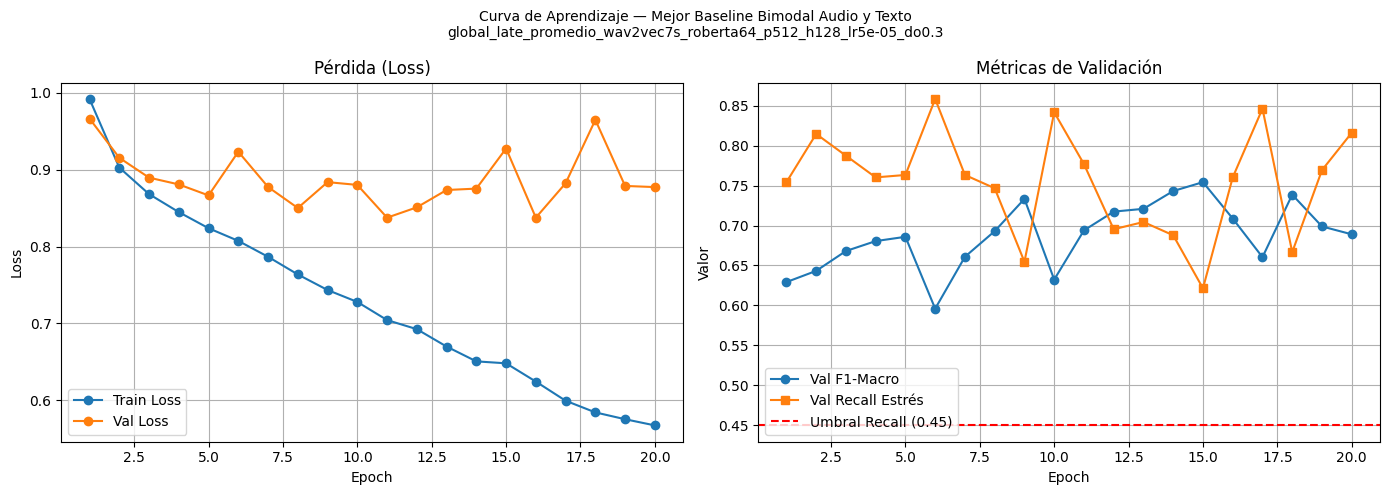

In [7]:
# ----------- MOSTRAMOS LOS RESULTADOS Y LA CURVA DE APRENDIZAJE DEL MEJOR MODELO -----------

mejor_config = "global_late_promedio_wav2vec7s_roberta64_p512_h128_lr5e-05_do0.3"

if mejor_config is not None:

    json_mejor = f"resultados/bimodales/dev/historial_estres_{mejor_config}.json"
    with open(json_mejor, 'r') as f:
        historial_mejor = json.load(f)

    print(f"\nMEJOR CONFIGURACIÓN FINAL: {mejor_config}")
    print(f"Mejor Val F1: {max(historial_mejor['val_f1']):.4f}")

    epochs_range = range(1, len(historial_mejor['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Curva de Aprendizaje — Mejor Baseline Bimodal Audio y Texto\n{mejor_config}", fontsize=10)

    # --- Subplot 1: Train Loss vs Val Loss ---
    axes[0].plot(epochs_range, historial_mejor['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(epochs_range, historial_mejor['val_loss'], label='Val Loss', marker='o')
    axes[0].set_title('Pérdida (Loss)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # --- Subplot 2: Val F1-Macro vs Val Recall Estrés ---
    axes[1].plot(epochs_range, historial_mejor['val_f1'], label='Val F1-Macro', marker='o')
    axes[1].plot(epochs_range, historial_mejor['val_recall_estres'],label='Val Recall Estrés', marker='s')
    axes[1].axhline(y=RECALL_ESTRES_MINIMO, color='red', linestyle='--', label=f'Umbral Recall ({RECALL_ESTRES_MINIMO})')
    axes[1].set_title('Métricas de Validación')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Valor')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(f"Fig_curva_aprendizaje_baseline_bimodal_audio_texto.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No se encontró ningún modelo que superara el filtro de Recall mínimo.")

--------
### **Comparativa final modelos bimodales en Validación (Corpus Unificado) por cada estrategia de fusión.**

In [14]:
rutas_todos_resultados = [
    #################################### VÍDEO Y AUDIO ################################
    {
        "baseline_bimodal": "Vídeo y Audio",
        "fusion": "Fusión Temprana",
        "historial": "pesos/bimodales_ajuste/bimodales_all/video_audio/historial_estres_global_early_resnet16_wav2vec11s_p512_h128_lr1e-05_do0.5.json",
        "modelo": "pesos/bimodales_ajuste/bimodales_all/video_audio/pesos_modelo_estres_global_early_resnet16_wav2vec11s_p512_h128_lr1e-05_do0.5.pth"
    },
    {
        "baseline_bimodal": "Vídeo y Audio",
        "fusion": "Fusión Tardía (Voto Mayoritario)",
        "historial": "pesos/bimodales_ajuste/bimodales_all/video_audio/historial_estres_global_late_voto_resnet16_wav2vec7s_p512_h128_lr1e-05_do0.5.json",
        "modelo": "pesos/bimodales_ajuste/bimodales_all/video_audio/pesos_modelo_estres_global_late_voto_resnet16_wav2vec7s_p512_h128_lr1e-05_do0.5.pth"
    },
    {
        "baseline_bimodal": "Vídeo y Audio",
        "fusion": "Fusión Tardía (Promedio)",
        "historial": "pesos/bimodales_ajuste/bimodales_all/video_audio/historial_estres_global_late_promedio_resnet32_wav2vec7s_p512_h128_lr1e-05_do0.5.json",
        "modelo": "pesos/bimodales_ajuste/bimodales_all/video_audio/pesos_modelo_estres_global_late_promedio_resnet32_wav2vec7s_p512_h128_lr1e-05_do0.5.pth"
    },
    {
        "baseline_bimodal": "Vídeo y Audio",
        "fusion": "Fusión Tardía (Regresión Logística)",
        "historial": "pesos/bimodales_ajuste/historial_estres_global_late_logistica_resnet16_wav2vec7s_p256_h64_lr1e-05_do0.3.json",
        "modelo": "pesos/bimodales_ajuste/pesos_modelo_estres_global_late_logistica_resnet16_wav2vec7s_p256_h64_lr1e-05_do0.3.pth"
    },
    {
        "baseline_bimodal": "Vídeo y Audio",
        "fusion": "Fusión mediante Atención",
        "historial": "pesos/bimodales_ajuste/bimodales_all/video_audio/historial_estres_global_attention_resnet16_wav2vec7s_p512_h128_lr5e-05_do0.3.json",
        "modelo": "pesos/bimodales_ajuste/bimodales_all/video_audio/pesos_modelo_estres_global_attention_resnet16_wav2vec7s_p512_h128_lr5e-05_do0.3.pth"
    },

    #################################### VÍDEO Y TEXTO ################################
    {
        "baseline_bimodal": "Vídeo y Texto",
        "fusion": "Fusión Temprana",
        "historial": "pesos/bimodales_ajuste/bimodales_all/video_texto/historial_estres_global_early_resnet32_roberta64_p512_h128_lr0.0001_do0.3.json",
        "modelo": "pesos/bimodales_ajuste/bimodales_all/video_texto/pesos_modelo_estres_global_early_resnet32_roberta64_p512_h128_lr0.0001_do0.3.pth"
    },
    {
        "baseline_bimodal": "Vídeo y Texto",
        "fusion": "Fusión Tardía (Voto Mayoritario)",
        "historial": "pesos/bimodales_ajuste/bimodales_all/video_texto/historial_estres_global_late_voto_resnet32_roberta64_p512_h128_lr0.0001_do0.5.json",
        "modelo": "pesos/bimodales_ajuste/bimodales_all/video_texto/pesos_modelo_estres_global_late_voto_resnet32_roberta64_p512_h128_lr0.0001_do0.5.pth"
    },
    {
        "baseline_bimodal": "Vídeo y Texto",
        "fusion": "Fusión Tardía (Promedio)",
        "historial": "pesos/bimodales_ajuste/bimodales_all/video_texto/historial_estres_global_late_promedio_resnet32_roberta64_p512_h128_lr0.0001_do0.3.json",
        "modelo": "pesos/bimodales_ajuste/bimodales_all/video_texto/pesos_modelo_estres_global_late_promedio_resnet32_roberta64_p512_h128_lr0.0001_do0.3.pth"
    },
    {
        "baseline_bimodal": "Vídeo y Texto",
        "fusion": "Fusión Tardía (Regresión Logística)",
        "historial": "pesos/bimodales_ajuste/historial_estres_global_late_logistica_resnet32_roberta64_p512_h128_lr0.0001_do0.5.json",
        "modelo": "pesos/bimodales_ajuste/pesos_modelo_estres_global_late_logistica_resnet32_roberta64_p512_h128_lr0.0001_do0.5.pth"
    },
    {
        "baseline_bimodal": "Vídeo y Texto",
        "fusion": "Fusión mediante Atención",
        "historial": "pesos/bimodales_ajuste/bimodales_all/video_texto/historial_estres_global_attention_resnet32_roberta32_p256_h64_lr0.0001_do0.3.json",
        "modelo": "pesos/bimodales_ajuste/bimodales_all/video_texto/pesos_modelo_estres_global_attention_resnet32_roberta32_p256_h64_lr0.0001_do0.3.pth"
    },

    #################################### AUDIO Y TEXTO ################################
    {
        "baseline_bimodal": "Audio y Texto",
        "fusion": "Fusión Temprana",
        "historial": "pesos/bimodales_ajuste/bimodales_all/audio_texto/historial_estres_global_early_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.3.json",
        "modelo": "pesos/bimodales_ajuste/bimodales_all/audio_texto/pesos_modelo_estres_global_early_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.3.pth"
    },
    {
        "baseline_bimodal": "Audio y Texto",
        "fusion": "Fusión Tardía (Voto Mayoritario)",
        "historial": "pesos/bimodales_ajuste/bimodales_all/audio_texto/historial_estres_global_late_voto_wav2vec11s_roberta64_p512_h128_lr0.0001_do0.3.json",
        "modelo": "pesos/bimodales_ajuste/bimodales_all/audio_texto/pesos_modelo_estres_global_late_voto_wav2vec11s_roberta64_p512_h128_lr0.0001_do0.3.pth"
    },
    {
        "baseline_bimodal": "Audio y Texto",
        "fusion": "Fusión Tardía (Promedio)",
        "historial": "pesos/bimodales_ajuste/historial_estres_global_late_promedio_wav2vec7s_roberta64_p512_h128_lr5e-05_do0.3.json",
        "modelo": "pesos/bimodales_ajuste/pesos_modelo_estres_global_late_promedio_wav2vec7s_roberta64_p512_h128_lr5e-05_do0.3.pth"
    }, 
    {
        "baseline_bimodal": "Audio y Texto",
        "fusion": "Fusión Tardía (Regresión Logística)",
        "historial": "pesos/bimodales_ajuste/bimodales_all/audio_texto/historial_estres_global_late_logistica_wav2vec7s_roberta64_p512_h128_lr0.0001_do0.3.json",
        "modelo": "pesos/bimodales_ajuste/bimodales_all/audio_texto/pesos_modelo_estres_global_late_logistica_wav2vec7s_roberta64_p512_h128_lr0.0001_do0.3.pth"
    },
    {
        "baseline_bimodal": "Audio y Texto",
        "fusion": "Fusión mediante Atención",
        "historial": "pesos/bimodales_ajuste/bimodales_all/audio_texto/historial_estres_global_attention_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3.json",
        "modelo": "pesos/bimodales_ajuste/bimodales_all/audio_texto/pesos_modelo_estres_global_attention_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3.pth"
    }
]

########### ---------- FUNCIÓN DE EXTRACCIÓN DE HIPERPARÁMETROS DEL NOMBRE DEL MODELO (.pth) ------------##############

def extraer_hiperparametros(nombre_archivo):
    """Extrae tamaño de las ventanas y arquitectura desde el nombre del archivo (.pth)"""
    
    # 1. Extracción de modalidades (bimodal)
    match_v = re.search(r'resnet(\d+)', nombre_archivo)
    v_win = match_v.group(1) if match_v else "N/A"
    
    match_a = re.search(r'wav2vec(\d+)s', nombre_archivo)
    a_win = match_a.group(1) if match_a else "N/A"
    
    match_t = re.search(r'roberta(\d+)', nombre_archivo)
    t_win = match_t.group(1) if match_t else "N/A"
    
    # 2. Extracción de hiperparámetros 
    try:
        proj = re.search(r'_p(\d+)', nombre_archivo).group(1) 
        hidden = re.search(r'_h(\d+)', nombre_archivo).group(1) 
        lr = re.search(r'_lr([\d.e-]+)', nombre_archivo).group(1) 
        dropout = re.search(r'_do([\d.]+)', nombre_archivo).group(1).rstrip('.') 
    except AttributeError:
        proj, hidden, lr, dropout = "N/A", "N/A", "N/A", "N/A"
        
    return v_win, a_win, t_win, proj, hidden, lr, dropout

datos_extraidos = []

for item in rutas_todos_resultados:
    ruta = item["historial"]
    
    if os.path.exists(ruta):
        with open (ruta, 'r', encoding='utf-8') as f:
            historial = json.load(f)
        f1 = max(historial['val_f1'])
        v_win, a_win, t_win, proj, hidden, lr, dropout = extraer_hiperparametros(item["modelo"])
        
        datos_extraidos.append({
            "Baseline Bimodal": item["baseline_bimodal"],
            "Fusión": item["fusion"],
            "V_frames": v_win,
            "A_seg": a_win,
            "T_tokens": t_win,
            "Proj_Dim": proj,
            "Hidden_MLP": hidden,
            "LR": lr,
            "Dropout": dropout,
            "F1-Score Macro": f1
        })
    else:
        print(f"No se encontró el archivo reporte para {item['baseline_bimodal']} en: {ruta_txt}")

# CREACIÓN Y EXPORTACIÓN DEL DATAFRAME
df_resultados_validacion = pd.DataFrame(datos_extraidos)

if not df_resultados_validacion.empty:
    
    # Exportamos a CSV 
    df_resultados_validacion.to_csv("resultados_bimodales_todos_validacion.csv", index=False)
    
    # Formato visual para mostrar en el notebook:
    columnas_colores = ['F1-Score Macro']
    styled_df = df_resultados_validacion.style.background_gradient(subset=columnas_colores, cmap='Purples')\
                                   .format({
                                       'F1-Score Macro': '{:.4f}'
                                   })\
                                   .set_caption("Evaluación Bimodales en Partición de Validación")
    
    display(styled_df)
else:
    print("\nNo se ha generado la tabla.")

,Baseline Bimodal,Fusión,V_frames,A_seg,T_tokens,Proj_Dim,Hidden_MLP,LR,Dropout,F1-Score Macro
0,Vídeo y Audio,Fusión Temprana,16,11,N/A,512,128,1e-05,0.5,0.5812
1,Vídeo y Audio,Fusión Tardía (Voto Mayoritario),16,7,N/A,512,128,1e-05,0.5,0.5798
2,Vídeo y Audio,Fusión Tardía (Promedio),32,7,N/A,512,128,1e-05,0.5,0.5782
3,Vídeo y Audio,Fusión Tardía (Regresión Logística),16,7,N/A,256,64,1e-05,0.3,0.5851
4,Vídeo y Audio,Fusión mediante Atención,16,7,N/A,512,128,5e-05,0.3,0.5847
5,Vídeo y Texto,Fusión Temprana,32,N/A,64,512,128,0.0001,0.3,0.7184
6,Vídeo y Texto,Fusión Tardía (Voto Mayoritario),32,N/A,64,512,128,0.0001,0.5,0.7031
7,Vídeo y Texto,Fusión Tardía (Promedio),32,N/A,64,512,128,0.0001,0.3,0.7093
8,Vídeo y Texto,Fusión Tardía (Regresión Logística),32,N/A,64,512,128,0.0001,0.5,0.7215
9,Vídeo y Texto,Fusión mediante Atención,32,N/A,32,256,64,0.0001,0.3,0.7191


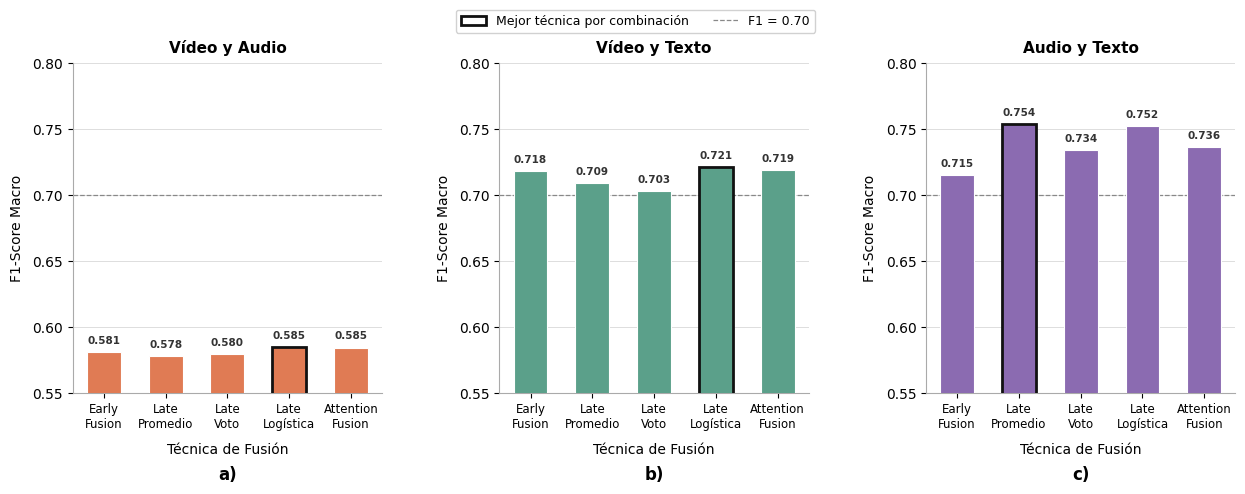

In [18]:
grupos = ["Vídeo y Audio", "Vídeo y Texto", "Audio y Texto"]

orden_fusiones = [ #Indicamos el orden para mostrar los modelos bimodales en la gráfica
    "Fusión Temprana",
    "Fusión Tardía (Promedio)",
    "Fusión Tardía (Voto Mayoritario)",
    "Fusión Tardía (Regresión Logística)",
    "Fusión mediante Atención",
]

# Construimos el diccionario por cada grupo con los valores de f1 macro directamente desde df_resultados_validacion
datasets = {}
for grupo in grupos:
    df_grupo = df_resultados_validacion[df_resultados_validacion["Baseline Bimodal"] == grupo]
    f1_vals = []
    for fusion in orden_fusiones: #debemos ir guardando los valores en orden para mostrarlos en ese mismo orden
        fila = df_grupo[df_grupo["Fusión"] == fusion]
        f1_vals.append(float(fila["F1-Score Macro"].values[0]) if not fila.empty else 0.0)
    datasets[grupo] = f1_vals

# ------------------------ GRÁFICA ------------------------

tecnicas = [
    "Early\nFusion",
    "Late\nPromedio",
    "Late\nVoto",
    "Late\nLogística",
    "Attention\nFusion",
]

BAR_COLORS = ["#E07B54", "#5BA08A", "#8B6BB1"]
subtitles  = ["a)", "b)", "c)"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
fig.subplots_adjust(wspace=0.38, bottom=0.22)

x = np.arange(len(tecnicas))
bar_width = 0.55

for ax, (dataset_name, f1_vals), color, subtitle in zip(
    axes, datasets.items(), BAR_COLORS, subtitles
):
    bars = ax.bar(x, f1_vals, width=bar_width, color=color,
                  edgecolor="white", linewidth=0.8, zorder=3)

    for bar, val in zip(bars, f1_vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{val:.3f}",
            ha="center", va="bottom",
            fontsize=7.5, color="#333333", fontweight="bold"
        )

    best_idx = int(np.argmax(f1_vals))
    bars[best_idx].set_edgecolor("#111111")
    bars[best_idx].set_linewidth(2.0)

    ax.set_ylim(0.55, 0.80)
    ax.set_yticks(np.arange(0.55, 0.81, 0.05))
    ax.set_ylabel("F1-Score Macro", fontsize=10, labelpad=6)
    ax.yaxis.grid(True, color="#DDDDDD", linewidth=0.7, zorder=0)
    ax.set_axisbelow(True)
    ax.set_xticks(x)
    ax.set_xticklabels(tecnicas, fontsize=8.5)
    ax.set_xlabel("Técnica de Fusión", fontsize=10, labelpad=8)
    ax.set_title(dataset_name, fontsize=11, fontweight="bold", pad=8)
    ax.text(0.5, -0.22, subtitle, transform=ax.transAxes,
            ha="center", va="top", fontsize=12, fontweight="bold")

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color("#AAAAAA")

for ax in axes:
    ax.axhline(0.70, color="#888888", linewidth=0.9,
               linestyle="--", zorder=2)

best_patch = mpatches.Patch(facecolor="white", edgecolor="#111111",
                             linewidth=2, label="Mejor técnica por combinación")
ref_line   = plt.Line2D([0], [0], color="#888888", linewidth=0.9,
                         linestyle="--", label="F1 = 0.70")
fig.legend(handles=[best_patch, ref_line], loc="upper center", ncol=2,
           fontsize=9, frameon=True, bbox_to_anchor=(0.5, 1.00),
           framealpha=0.9, edgecolor="#CCCCCC")

plt.savefig("Fig_Seleccion_Bimodales_Validacion.pdf",
            dpi=300, bbox_inches="tight", format="pdf")
plt.show()

----
## **Evaluación en Test (Corpus Global) de los baselines bimodales seleccionados**

* **Vídeo + Audio**

In [3]:
path_pesos = 'pesos/bimodales_ajuste/pesos_modelo_estres_global_late_logistica_resnet16_wav2vec7s_p256_h64_lr1e-05_do0.3.pth'

comando = (f"python evaluate.py "
           f"--model_path {path_pesos} "
           f"--eval_dataset global "
           f"--split test "
           f"--fusion late "
           f"--late_mode logistica "
           f"--video resnet "
           f"--video_frames 16 "
           f"--audio wav2vec "
           f"--audio_len 7 "
           f"--proj_dim 256 "
           f"--hidden_mlp 64 "
           f"--dropout 0.3 ")
                        
subprocess.run(comando, shell=True)

100%|██████████| 4257/4257 [00:18<00:00, 231.83it/s]


MÉTRICAS DEL MODELO EN TEST:
Parámetros Totales: 6,530,565
Parámetros Entrenables: 6,530,565
Tiempo medio de Inferencia: 3.22 ms / muestra
ROC-AUC Score: 0.6525
F1 Macro: 0.6050
F1 Weighted: 0.7055
Accuracy (en %): 68.92%
Balanced Accuracy (en %): 62.42%


CompletedProcess(args='python evaluate.py --model_path pesos/bimodales_ajuste/pesos_modelo_estres_global_late_logistica_resnet16_wav2vec7s_p256_h64_lr1e-05_do0.3.pth --eval_dataset global --split test --fusion late --late_mode logistica --video resnet --video_frames 16 --audio wav2vec --audio_len 7 --proj_dim 256 --hidden_mlp 64 --dropout 0.3 ', returncode=0)

* **Vídeo + Texto**

In [4]:
path_pesos = 'pesos/bimodales_ajuste/pesos_modelo_estres_global_late_logistica_resnet32_roberta64_p512_h128_lr0.0001_do0.5.pth'

comando = (f"python evaluate.py "
           f"--model_path {path_pesos} "
           f"--eval_dataset global "
           f"--split test "
           f"--fusion late "
           f"--late_mode logistica "
           f"--video resnet "
           f"--video_frames 32 "
           f"--text roberta64 "
           f"--proj_dim 512 "
           f"--hidden_mlp 128 "
           f"--dropout 0.5 ")
                        
subprocess.run(comando, shell=True)

100%|██████████| 4257/4257 [00:06<00:00, 660.35it/s]


MÉTRICAS DEL MODELO EN TEST:
Parámetros Totales: 6,038,533
Parámetros Entrenables: 6,038,533
Tiempo medio de Inferencia: 0.80 ms / muestra
ROC-AUC Score: 0.7822
F1 Macro: 0.7039
F1 Weighted: 0.7935
Accuracy (en %): 79.33%
Balanced Accuracy (en %): 70.43%


CompletedProcess(args='python evaluate.py --model_path pesos/bimodales_ajuste/pesos_modelo_estres_global_late_logistica_resnet32_roberta64_p512_h128_lr0.0001_do0.5.pth --eval_dataset global --split test --fusion late --late_mode logistica --video resnet --video_frames 32 --text roberta64 --proj_dim 512 --hidden_mlp 128 --dropout 0.5 ', returncode=0)

* **Audio + Texto**

In [5]:
path_pesos = 'pesos/bimodales_ajuste/pesos_modelo_estres_global_late_promedio_wav2vec7s_roberta64_p512_h128_lr5e-05_do0.3.pth'

comando = (f"python evaluate.py "
           f"--model_path {path_pesos} "
           f"--eval_dataset global "
           f"--split test "
           f"--fusion late "
           f"--late_mode promedio "
           f"--audio wav2vec "
           f"--audio_len 7 "
           f"--text roberta64 "
           f"--proj_dim 512 "
           f"--hidden_mlp 128 "
           f"--dropout 0.3 ")
                        
subprocess.run(comando, shell=True)

100%|██████████| 4257/4257 [00:16<00:00, 251.86it/s]


MÉTRICAS DEL MODELO EN TEST:
Parámetros Totales: 3,417,090
Parámetros Entrenables: 3,417,090
Tiempo medio de Inferencia: 3.00 ms / muestra
ROC-AUC Score: 0.8126
F1 Macro: 0.7194
F1 Weighted: 0.8066
Accuracy (en %): 80.88%
Balanced Accuracy (en %): 71.47%


CompletedProcess(args='python evaluate.py --model_path pesos/bimodales_ajuste/pesos_modelo_estres_global_late_promedio_wav2vec7s_roberta64_p512_h128_lr5e-05_do0.3.pth --eval_dataset global --split test --fusion late --late_mode promedio --audio wav2vec --audio_len 7 --text roberta64 --proj_dim 512 --hidden_mlp 128 --dropout 0.3 ', returncode=0)

Tabla Final Comparativa:

In [7]:
#  Definimos las rutas exactas de los 3 modelos campeones evaluados en TEST
rutas_resultados = [
    {
        "baseline_bimodal": "Vídeo y Audio",
        "fusion": "Fusión Tardía (Regresión Logística)",
        "reporte": "resultados/bimodales_test/reporte_pesos_modelo_estres_global_late_logistica_resnet16_wav2vec7s_p256_h64_lr1e-05_do0.3_global_test.txt",
        "modelo": "pesos/bimodales_ajuste/pesos_modelo_estres_global_late_logistica_resnet16_wav2vec7s_p256_h64_lr1e-05_do0.3.pth"
    },
    {
        "baseline_bimodal": "Vídeo y Texto",
        "fusion": "Fusión Tardía (Regresión Logística)",
        "reporte": "resultados/bimodales_test/reporte_pesos_modelo_estres_global_late_logistica_resnet32_roberta64_p512_h128_lr0.0001_do0.5_global_test.txt",
        "modelo": "pesos/bimodales_ajuste/pesos_modelo_estres_global_late_logistica_resnet32_roberta64_p512_h128_lr0.0001_do0.5.pth"
    },
    {
        "baseline_bimodal": "Audio y Texto",
        "fusion": "Fusión Tardía (Promedio)",
        "reporte": "resultados/bimodales_test/reporte_pesos_modelo_estres_global_late_promedio_wav2vec7s_roberta64_p512_h128_lr5e-05_do0.3_global_test.txt",
        "modelo": "pesos/bimodales_ajuste/pesos_modelo_estres_global_late_promedio_wav2vec7s_roberta64_p512_h128_lr5e-05_do0.3.pth"
    }
]

########### ---------- FUNCIÓN DE EXTRACCIÓN DE MÉTRICAS A PARTIR DEL REPORTE .txt ------------##############

def extraer_metricas_txt(ruta_txt):
    """
    Abre el reporte .txt y extrae el F1-Score Macro, Balanced Accuracy, el ROC-AUC y el Recall de la clase 'Estrés'
    """
    f1_macro = 0.0
    auc = 0.0
    ba = 0.0
    recall_estres = 0.0
    
    if not os.path.exists(ruta_txt):
        print(f"No se encuentra el archivo {ruta_txt}")
        return f1_macro, auc, recall_estres
        
    with open(ruta_txt, 'r', encoding='utf-8') as f:
        lineas = f.readlines()
        
    for linea in lineas:
        if "Balanced Accuracy" in linea:
            ba = float(linea.split(":")[1].strip())
        if "ROC-AUC:" in linea:
            auc = float(linea.split(":")[1].strip())
        elif "macro avg" in linea:
            # Ejemplo de línea que puede estar en el reporte: "macro avg    0.80      0.79      0.79       200"
            partes = linea.split()
            f1_macro = float(partes[4]) # El F1-Score está en la 5ª columna
        elif linea.strip().startswith("Estrés"):
            # Ejemplo de línea típica: "   Estrés       0.85      0.82      0.83       100"
            # partes[0]='Estrés', partes[1]=Precision, partes[2]=Recall
            partes = linea.split()
            recall_estres = float(partes[2])
            
    return f1_macro, ba, auc, recall_estres

datos_extraidos = []

for item in rutas_resultados:
    ruta_txt = item["reporte"]
    
    if os.path.exists(ruta_txt):
        f1, ba, auc, recall = extraer_metricas_txt(ruta_txt)
        v_win, a_win, t_win, proj, hidden, lr, dropout = extraer_hiperparametros(item["modelo"])
        
        datos_extraidos.append({
            "Baseline Bimodal": item["baseline_bimodal"],
            "Fusión": item["fusion"],
            "V_frames": v_win,
            "A_seg": a_win,
            "T_tokens": t_win,
            "Proj_Dim": proj,
            "Hidden_MLP": hidden,
            "LR": lr,
            "Dropout": dropout,
            "F1-Score Macro": f1,
            "Balanced Accuracy": ba,
            "ROC-AUC": auc,
            "Recall (Estrés)": recall
        })
    else:
        print(f"No se encontró el archivo reporte para {item['baseline_bimodal']} en: {ruta_txt}")

# CREACIÓN Y EXPORTACIÓN DEL DATAFRAME
df_resultados = pd.DataFrame(datos_extraidos)

if not df_resultados.empty:
    # Ordenamos por F1-Score Macro
    df_resultados = df_resultados.sort_values(by="F1-Score Macro", ascending=False).reset_index(drop=True)
    
    # Exportamos a CSV 
    df_resultados.to_csv("resultados_finales_bimodales_seleccionados_test.csv", index=False)
    
    # Formato visual para mostrar en el notebook:
    columnas_colores = ['F1-Score Macro', 'Balanced Accuracy', 'ROC-AUC', 'Recall (Estrés)']
    styled_df = df_resultados.style.background_gradient(subset=columnas_colores, cmap='Purples')\
                                   .format({
                                       'F1-Score Macro': '{:.4f}',
                                       'Balanced Accuracy': '{:.4f}',
                                       'ROC-AUC': '{:.4f}',
                                       'Recall (Estrés)': '{:.4f}'
                                   })\
                                   .set_caption("Evaluación Final en Partición de TEST - Modelos Seleccionados")
    
    display(styled_df)
else:
    print("\nNo se ha generado la tabla.")

,Baseline Bimodal,Fusión,V_frames,A_seg,T_tokens,Proj_Dim,Hidden_MLP,LR,Dropout,F1-Score Macro,Balanced Accuracy,ROC-AUC,Recall (Estrés)
0,Audio y Texto,Fusión Tardía (Promedio),N/A,7,64,512,128,5e-05,0.3,0.7194,0.7147,0.8126,0.5439
1,Vídeo y Texto,Fusión Tardía (Regresión Logística),32,N/A,64,512,128,0.0001,0.5,0.7039,0.7043,0.7822,0.5429
2,Vídeo y Audio,Fusión Tardía (Regresión Logística),16,7,N/A,256,64,1e-05,0.3,0.6050,0.6242,0.6525,0.5063


Podemos observer que todos los modelos bimodales ajustados obtienen mejores rendimientos para la fusión tardía, presentando el mejor modelo (el que alcanza el mayor valor en las 4 métricas consideradas) la **fusión tardía mediante promedio** para **audio y texto**. Ante el ruido aportado, principalmente, por MELD, y la dificultad de la tarea ante la unificación de dominios, el modelo mejora en rendimiento con una fusión a nivel de decisión, procesando cada modalidad individualmente, y finalmente promediando. Lo que puede estar ocurriendo es que el promedio esté "salvando" las predicciones del modelo y por tanto, de las modalidades individuales. Para poder comprobar la capacidad real de generalización del modelo, se enfrentará al tercer dataset de MSP-IMPROV en la evaluación de transferencia de aprendizaje. 